## **TRABAJO FINAL — Business Predictive Analytics**
### Sistema de Analítica Predictiva para la Gestión de la Capacidad Hotelera
**Dataset:** Indicadores de Ocupabilidad Hotelera 2024 — MINCETUR

## 1. Cargamos: Librerías y Carga de Datos

> Importamos todas las librerías necesarias para el pipeline completo:
> limpieza, EDA, encoding, escalado y feature engineering.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OneHotEncoder, RobustScaler, StandardScaler, PowerTransformer,
    Binarizer, FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
pd.options.display.float_format = '{:.3f}'.format
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

def mostrar_caption(numero, texto):
    display(Markdown(f'**Figura {numero}:** {texto}'))

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/LABS/00_DATASETS/Indicadores_ocupabilidad_2024.csv",encoding='latin-1', sep=';')
pd.set_option('display.max_columns', None)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head(5)

Dataset cargado: 6,151 filas × 24 columnas


,FECHA_CORTE,ANIO,MES,ID_CLASE,CLASE,ID_CATEGORIA,CATEGORIA,DEPARTAMENTO,ID_UBIGEO,NUMERO_ESTABLECIMIENTOS,NUMERO_HABITACIONES,NUMERO_PLAZAS_CAMA,PORCENTAJE_TNOH,PORCENTAJE_TNOC,PROMEDIO_PERMANENCIA,PROMEDIO_PERMANENCIA_NAC,PROMEDIO_PERMANENCIA_EXT,TOTAL_ARRIBOS,TOTAL_ARRIBOS_NAC,TOTAL_ARRIBOS_EXT,TOTAL_PERNOCT,TOTAL_PERNOCT_NAC,TOTAL_PERNOCT_EXT,TOTAL_EMPLEO
0,20260330,2024,1,00,NO CLASIFICADO,00,NO CATEGORIZADO,AMAZONAS,10000,302,2891,4530,"12,63","9,36","1,3","1,28","1,53",10143,9642,501,13139,12373,766,538
1,20260330,2024,1,00,NO CLASIFICADO,00,NO CATEGORIZADO,ÁNCASH,20000,719,6308,10671,"18,62","13,66","1,17","1,18","1,07",38666,34928,3738,45201,41212,3989,1162
2,20260330,2024,1,00,NO CLASIFICADO,00,NO CATEGORIZADO,APURÍMAC,30000,510,4503,7047,"19,27","14,28","1,15","1,15","1,13",27188,27074,114,31186,31057,129,441
3,20260330,2024,1,00,NO CLASIFICADO,TT,TODAS CONSOLIDADAS,AMAZONAS,10000,302,2891,4530,"12,63","9,36","1,3","1,28","1,53",10143,9642,501,13139,12373,766,538
4,20260330,2024,1,00,NO CLASIFICADO,TT,TODAS CONSOLIDADAS,ÁNCASH,20000,719,6308,10671,"18,62","13,66","1,17","1,18","1,07",38666,34928,3738,45201,41212,3989,1162


---
## 2. Calidad y Limpieza de Datos

> En esta fase vamos a documentar los problemas y como resolvimos.

In [ ]:
df.shape

(6151, 24)

### 2.2 Data Type Mismatch
Problema encontrado: Las columnas PORCENTAJE_TNOH, PORCENTAJE_TNOC y PROMEDIO_PERMANENCIA* están guardadas como object porque usan coma para el separador decimal.

Solución: Convertir a `float64` en tres pasos: `astype(str)` → `str.replace(',','.')` → `astype(float)`.


In [ ]:
columnas_convertir = [
    'PORCENTAJE_TNOH', 'PORCENTAJE_TNOC',
    'PROMEDIO_PERMANENCIA', 'PROMEDIO_PERMANENCIA_NAC', 'PROMEDIO_PERMANENCIA_EXT'
]
for col in columnas_convertir:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False).astype(float)

print("Tipos después de la conversión:")
df[columnas_convertir].dtypes

Tipos después de la conversión:


,0
PORCENTAJE_TNOH,float64
PORCENTAJE_TNOC,float64
PROMEDIO_PERMANENCIA,float64
PROMEDIO_PERMANENCIA_NAC,float64
PROMEDIO_PERMANENCIA_EXT,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6151 entries, 0 to 6150
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FECHA_CORTE               6151 non-null   int64  
 1   ANIO                      6151 non-null   int64  
 2   MES                       6151 non-null   int64  
 3   ID_CLASE                  6151 non-null   object 
 4   CLASE                     6151 non-null   object 
 5   ID_CATEGORIA              6151 non-null   object 
 6   CATEGORIA                 6151 non-null   object 
 7   DEPARTAMENTO              6151 non-null   object 
 8   ID_UBIGEO                 6151 non-null   int64  
 9   NUMERO_ESTABLECIMIENTOS   6151 non-null   int64  
 10  NUMERO_HABITACIONES       6151 non-null   int64  
 11  NUMERO_PLAZAS_CAMA        6151 non-null   int64  
 12  PORCENTAJE_TNOH           6151 non-null   float64
 13  PORCENTAJE_TNOC           6151 non-null   float64
 14  PROMEDIO

In [ ]:
df.dtypes

,0
FECHA_CORTE,int64
ANIO,int64
MES,int64
ID_CLASE,object
CLASE,object
ID_CATEGORIA,object
CATEGORIA,object
DEPARTAMENTO,object
ID_UBIGEO,int64
NUMERO_ESTABLECIMIENTOS,int64


### 2.3 Uniform Data — Valores Únicos y Duplicados

In [ ]:
# Valores únicos por columna (verificar consistencia)
df.nunique().sort_values(ascending=True)

,0
FECHA_CORTE,1
ANIO,1
ID_CLASE,8
CLASE,8
CATEGORIA,9
ID_CATEGORIA,9
MES,12
DEPARTAMENTO,25
ID_UBIGEO,25
PROMEDIO_PERMANENCIA_NAC,251


In [ ]:
# Duplicados — esperamos 0 para un dataset oficial de MINCETUR
print(f"Filas duplicadas: {df.duplicated().sum()}")
df[df.duplicated()]

Filas duplicadas: 0


,FECHA_CORTE,ANIO,MES,ID_CLASE,CLASE,ID_CATEGORIA,CATEGORIA,DEPARTAMENTO,ID_UBIGEO,NUMERO_ESTABLECIMIENTOS,NUMERO_HABITACIONES,NUMERO_PLAZAS_CAMA,PORCENTAJE_TNOH,PORCENTAJE_TNOC,PROMEDIO_PERMANENCIA,PROMEDIO_PERMANENCIA_NAC,PROMEDIO_PERMANENCIA_EXT,TOTAL_ARRIBOS,TOTAL_ARRIBOS_NAC,TOTAL_ARRIBOS_EXT,TOTAL_PERNOCT,TOTAL_PERNOCT_NAC,TOTAL_PERNOCT_EXT,TOTAL_EMPLEO


#### Filas con al menos 16 datos válidos

 Equivale al 67% de las 24 columnas. Garantiza que todas las variables
> Analíticas clave (TNOH, TOTAL_ARRIBOS, NUMERO_HABITACIONES, PROMEDIO_PERMANENCIA)
> estén presentes. Un registro con menos del 67% requeriría imputación especulativa.

In [ ]:
conteo = df.notna().sum(axis=1)
filas_validas = (conteo >= 16).sum()
print(f"Filas con al menos 16 datos válidos: {filas_validas} de {len(df)}")
# Si todas pasan, el dataset está completamente poblado

Filas con al menos 16 datos válidos: 6151 de 6151


In [ ]:
df.dropna(thresh=16, inplace=True)
print(f"Shape después de filtro: {df.shape}")

Shape después de filtro: (6151, 24)


In [ ]:
# Columnas con al menos 3,000 datos válidos de los 6,151
conteo_validos = df.notna().sum(axis=0)
columnas_validas = (conteo_validos >= 3000).sum()
print(f"Columnas con al menos 3,000 datos válidos: {columnas_validas} de {df.shape[1]}")
# Todas las columnas son válidas

Columnas con al menos 3,000 datos válidos: 24 de 24


In [ ]:
# Configuración de gráficos para outliers
plt.rcParams['figure.figsize'] = (10, 5)

#### Frecuencia por categorías clave (detección visual de concentraciones)

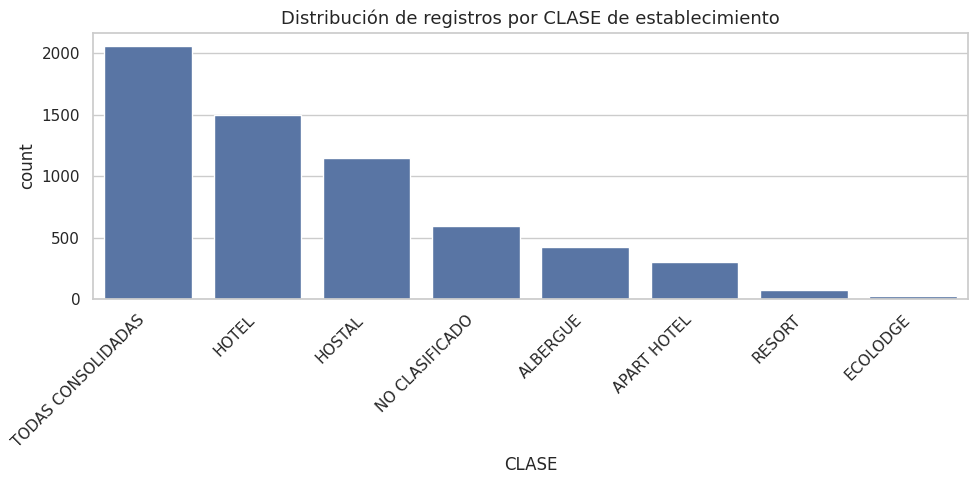

**Figura 13:** Frecuencia de registros por clase de establecimiento

In [ ]:
sns.countplot(data=df, x='CLASE', order=df['CLASE'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Distribución de registros por CLASE de establecimiento')
plt.tight_layout()
plt.show()
mostrar_caption(13, 'Frecuencia de registros por clase de establecimiento')

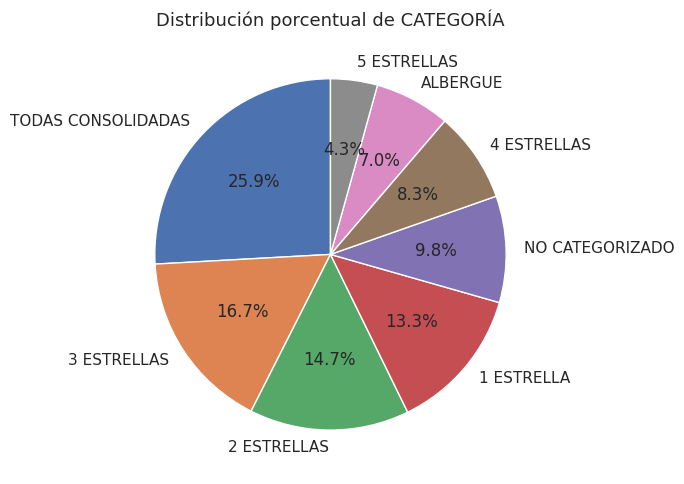

**Figura 14:** Distribución porcentual de CATEGORÍA de establecimiento

In [ ]:
if 'CATEGORIA' in df.columns:
    valores = df['CATEGORIA'].value_counts().head(8)
    plt.pie(valores.values, labels=valores.index, autopct='%1.1f%%', startangle=90)
    plt.title('Distribución porcentual de CATEGORÍA')
    plt.tight_layout()
    plt.show()
    mostrar_caption(14, 'Distribución porcentual de CATEGORÍA de establecimiento')

#### Distribución de variables numéricas

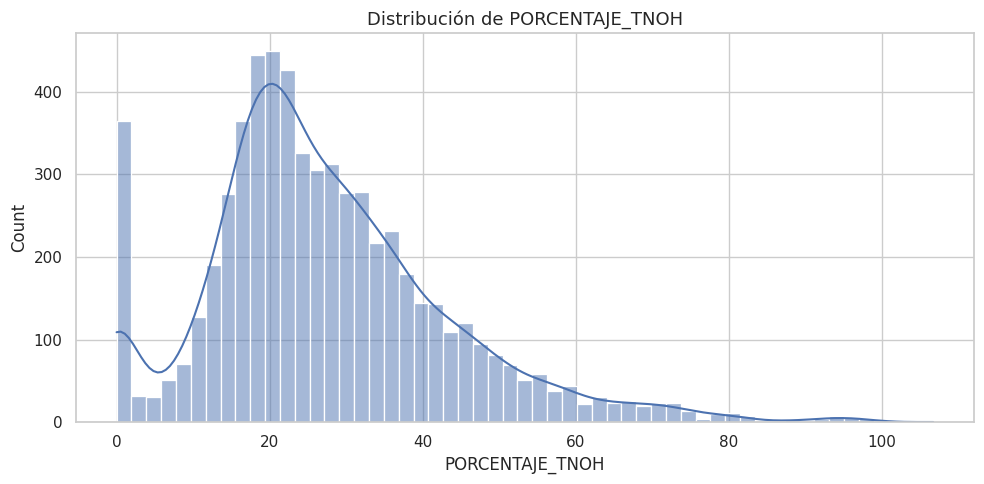

**Figura 15:** Distribución de la variable PORCENTAJE_TNOH

In [ ]:
sns.histplot(df['PORCENTAJE_TNOH'].dropna(), kde=True)
plt.title('Distribución de PORCENTAJE_TNOH')
plt.xlabel('PORCENTAJE_TNOH')
plt.tight_layout()
plt.show()
mostrar_caption(15, 'Distribución de la variable PORCENTAJE_TNOH')

#### Distribución temporal de la ocupabilidad

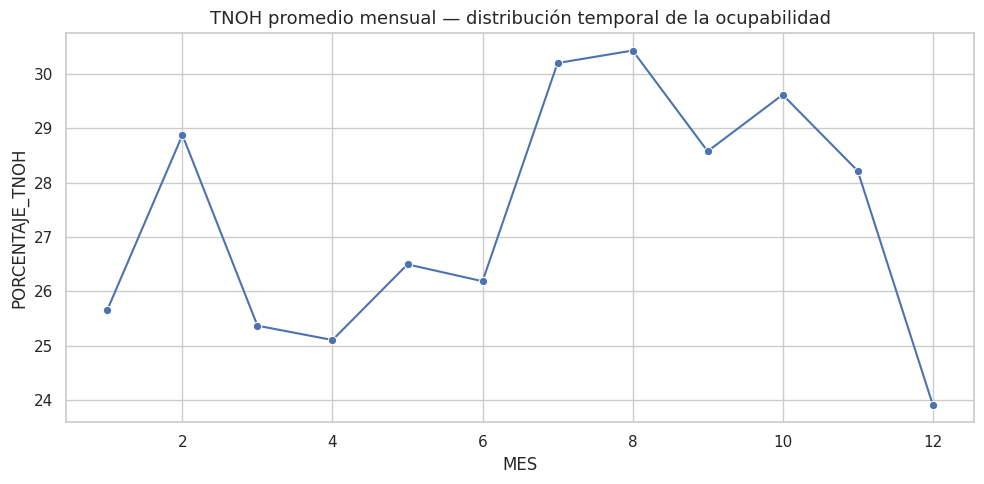

**Figura 16:** TNOH promedio mensual — distribución temporal de la ocupabilidad

In [ ]:
tnoh_mes = df.groupby('MES', as_index=False)['PORCENTAJE_TNOH'].mean().sort_values('MES')
sns.lineplot(data=tnoh_mes, x='MES', y='PORCENTAJE_TNOH', marker='o')
plt.title('TNOH promedio mensual — distribución temporal de la ocupabilidad')
plt.tight_layout()
plt.show()
mostrar_caption(16, 'TNOH promedio mensual — distribución temporal de la ocupabilidad')

#### Distribución de registros por mes (verificación de uniformidad)

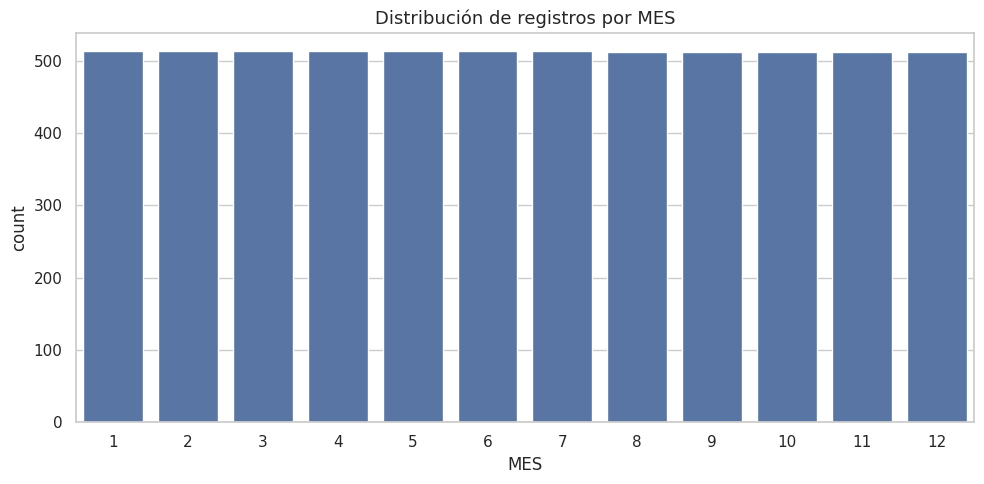

**Figura 17:** Distribución de registros por mes

In [ ]:
sns.countplot(data=df, x='MES', order=sorted(df['MES'].dropna().unique()))
plt.title('Distribución de registros por MES')
plt.tight_layout()
plt.show()
mostrar_caption(17, 'Distribución de registros por mes')

#### Validación de rangos de negocio

> Por definición, TNOH y TNOC deben estar entre 0 y 100.

PORCENTAJE_TNOH: 1 registros fuera del rango [0, 100]


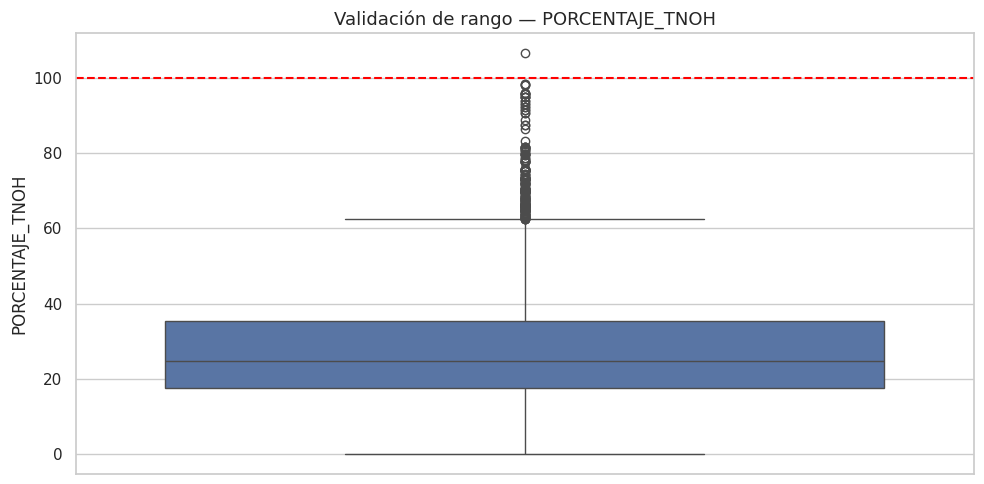

PORCENTAJE_TNOC: 3 registros fuera del rango [0, 100]


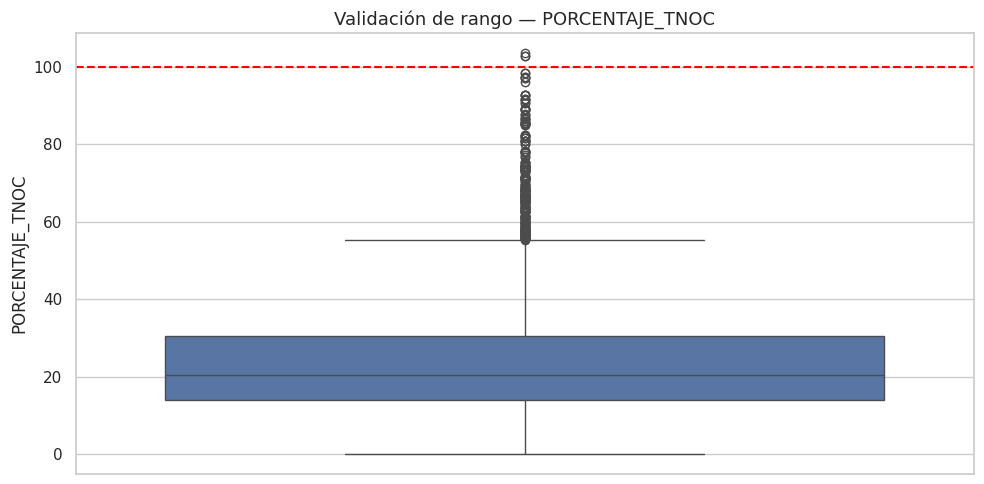

In [ ]:
for col in ['PORCENTAJE_TNOH', 'PORCENTAJE_TNOC']:
    fuera = df[(df[col] < 0) | (df[col] > 100)]
    print(f"{col}: {len(fuera)} registros fuera del rango [0, 100]")
    sns.boxplot(y=df[col])
    plt.axhline(100, color='red', linestyle='--', label='Límite máximo (100%)')
    plt.title(f'Validación de rango — {col}')
    plt.tight_layout()
    plt.show()

#### Detección de outliers mediante IQR (umbral estándar 1.5×IQR)

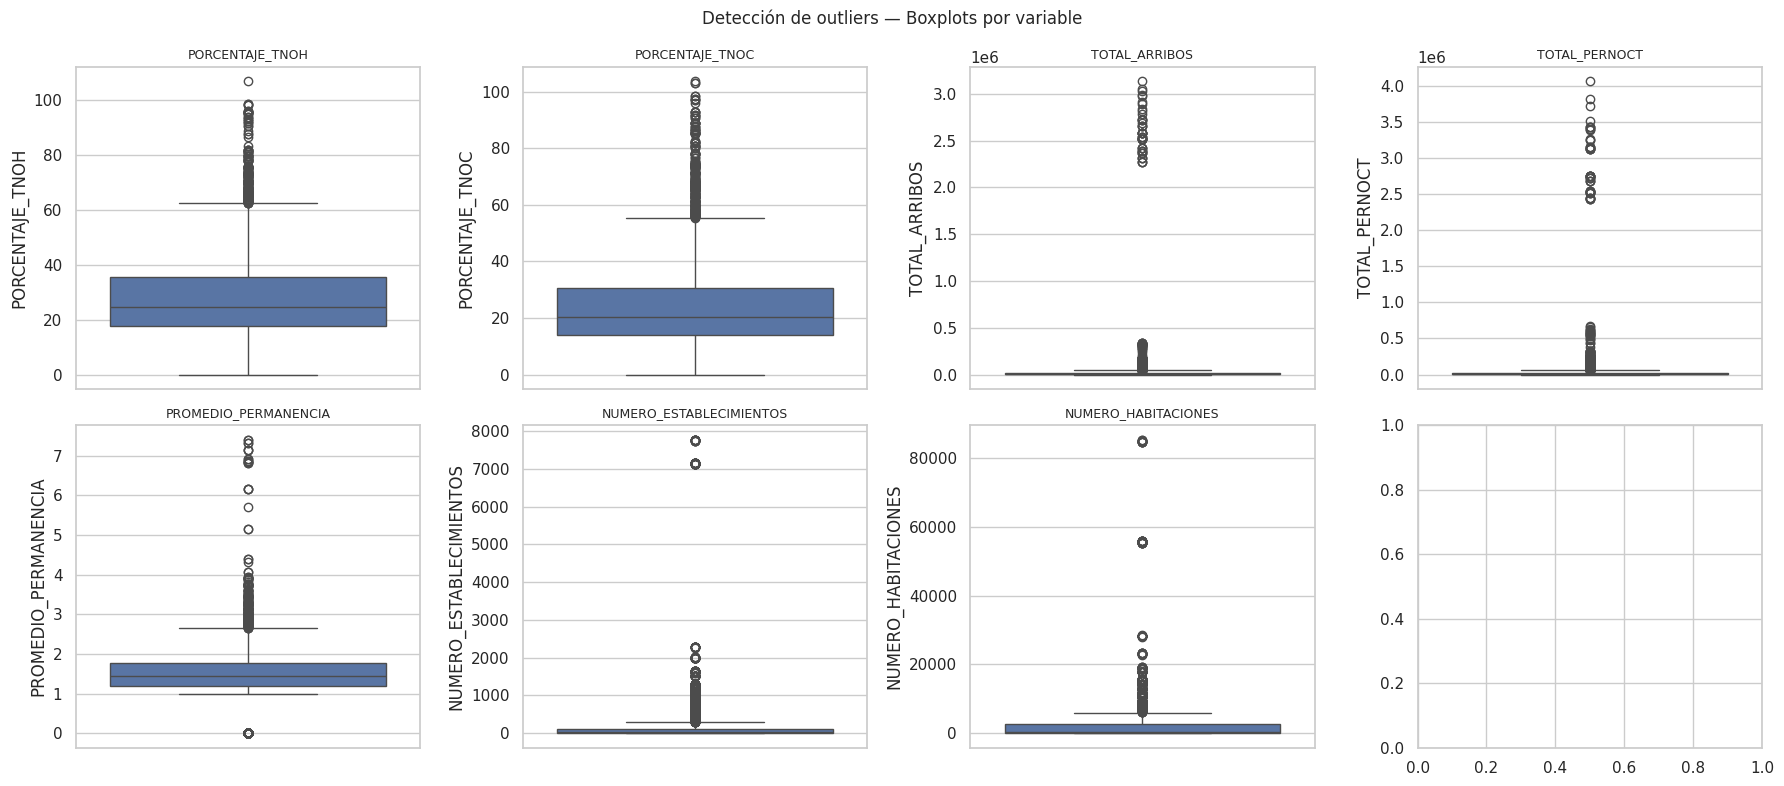

**Figura 21:** Detección de outliers mediante IQR — boxplots de variables

In [ ]:
variables_iqr = [
    'PORCENTAJE_TNOH', 'PORCENTAJE_TNOC', 'TOTAL_ARRIBOS', 'TOTAL_PERNOCT',
    'PROMEDIO_PERMANENCIA', 'NUMERO_ESTABLECIMIENTOS', 'NUMERO_HABITACIONES', 'NUMERO_CAMAS'
]
variables_iqr = [col for col in variables_iqr if col in df.columns]

# Boxplots para visualizar outliers
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(variables_iqr):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=9)
plt.suptitle('Detección de outliers — Boxplots por variable', fontsize=12)
plt.tight_layout()
plt.show()
mostrar_caption(21, 'Detección de outliers mediante IQR — boxplots de variables')

In [ ]:
# Resumen cuantitativo de outliers por variable
outlier_summary = []
for col in variables_iqr:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    cantidad = ((df[col] < li) | (df[col] > ls)).sum()
    outlier_summary.append({'variable': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
                            'Límite_inf': li, 'Límite_sup': ls, 'Outliers': cantidad})

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)
mostrar_caption(22, 'Detección de outliers mediante IQR — resumen por variable')

,variable,Q1,Q3,IQR,Límite_inf,Límite_sup,Outliers
0,PORCENTAJE_TNOH,17.550,35.480,17.930,-9.345,62.375,210
1,PORCENTAJE_TNOC,13.925,30.450,16.525,-10.862,55.237,267
2,TOTAL_ARRIBOS,1017.000,18906.000,17889.000,-25816.500,45739.500,665
3,TOTAL_PERNOCT,1631.000,27248.000,25617.000,-36794.500,65673.500,711
4,PROMEDIO_PERMANENCIA,1.180,1.770,0.590,0.295,2.655,570
5,NUMERO_ESTABLECIMIENTOS,4.000,122.000,118.000,-173.000,299.000,1014
6,NUMERO_HABITACIONES,131.000,2540.000,2409.000,-3482.500,6153.500,696


**Figura 22:** Detección de outliers mediante IQR — resumen por variable

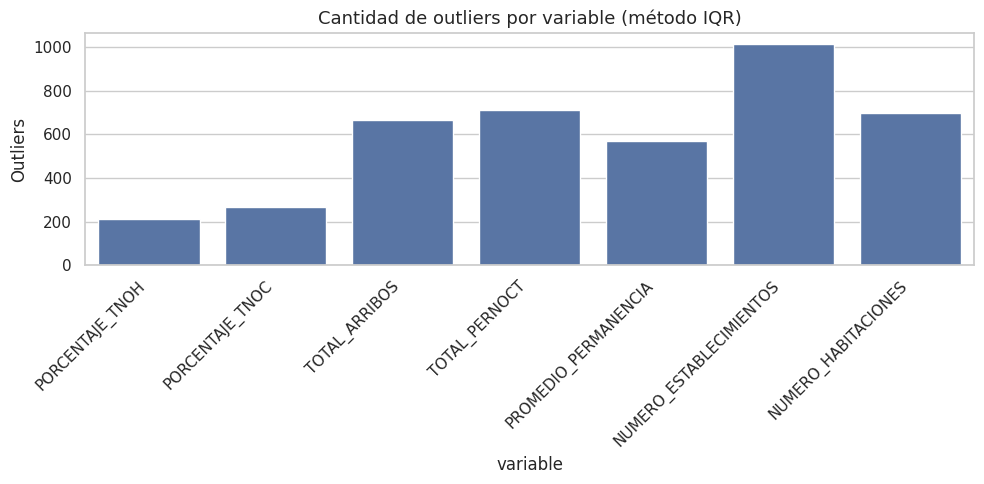

**Figura 23:** Resumen de valores atípicos detectados por variable numérica

In [ ]:
# Gráfico de cantidad de outliers por variable
sns.barplot(data=outlier_df, x='variable', y='Outliers')
plt.title('Cantidad de outliers por variable (método IQR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
mostrar_caption(23, 'Resumen de valores atípicos detectados por variable numérica')

### 2.5 Missing Data

> Se verifica la ausencia de valores nulos. El dataset de MINCETUR es un dataset oficial
> agregado — los datos son validados antes de publicarse.

,valores_nulos
FECHA_CORTE,0
ANIO,0
MES,0
ID_CLASE,0
CLASE,0
ID_CATEGORIA,0
CATEGORIA,0
DEPARTAMENTO,0
ID_UBIGEO,0
NUMERO_ESTABLECIMIENTOS,0


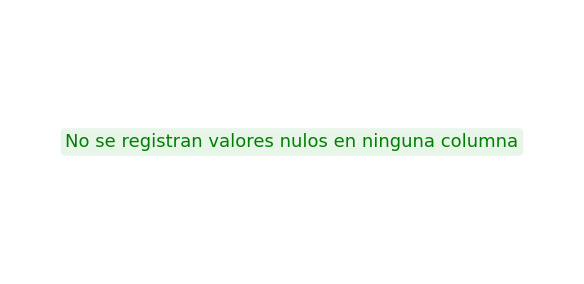

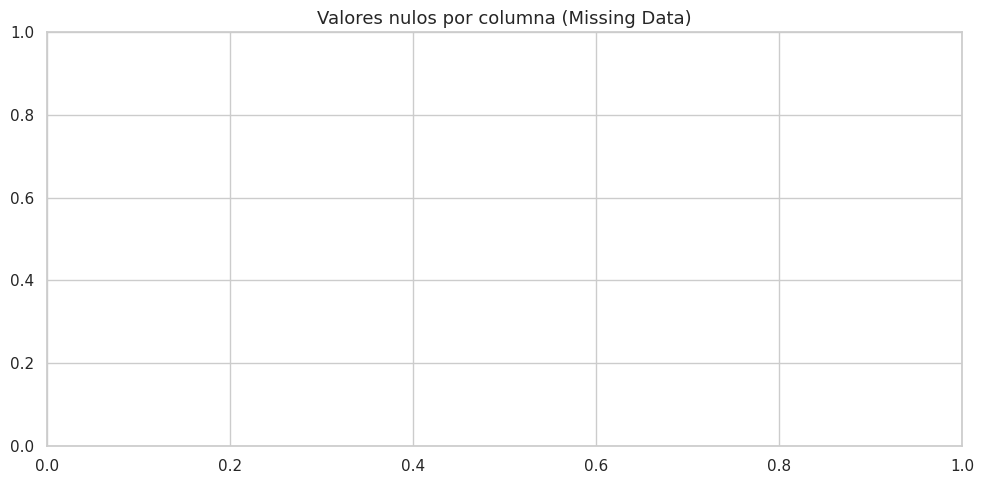

**Figura 24:** Valores nulos por columna — Missing Data

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_df = pd.DataFrame({'valores_nulos': missing})
display(missing_df)

faltantes = missing_df[missing_df['valores_nulos'] > 0]
if len(faltantes) == 0:
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.text(0.5, 0.5, 'No se registran valores nulos en ninguna columna',
            ha='center', va='center', fontsize=13, color='green',
            bbox=dict(boxstyle='round', facecolor='#e8f5e9'))
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    sns.barplot(data=faltantes.reset_index(), x='index', y='valores_nulos')
    plt.xticks(rotation=45, ha='right')
plt.title('Valores nulos por columna (Missing Data)')
plt.tight_layout()
plt.show()
mostrar_caption(24, 'Valores nulos por columna — Missing Data')

---
## 3. EDA — Análisis Exploratorio de Datos

> El EDA identifica patrones, distribuciones y relaciones entre variables:
> Usamos el subconjunto CLASE = 'TODAS CONSOLIDADAS' (1,584 registros) para evitar
> doble contabilización por segmento. Incluye análisis univariado y bivariado
> siguiendo la metodología del curso.

In [ ]:
# Subconjunto principal: TODAS CONSOLIDADAS (evita doble conteo)
if 'CLASE' in df.columns:
    df_eda = df[df['CLASE'].astype(str).str.upper().str.contains('TODAS', na=False)].copy()
    if df_eda.empty:
        df_eda = df.copy()
else:
    df_eda = df.copy()

print(f"Registros en subconjunto TODAS CONSOLIDADAS: {len(df_eda):,}")

Registros en subconjunto TODAS CONSOLIDADAS: 2,064


### Análisis 1: TNOH promedio por departamento (Top 10)

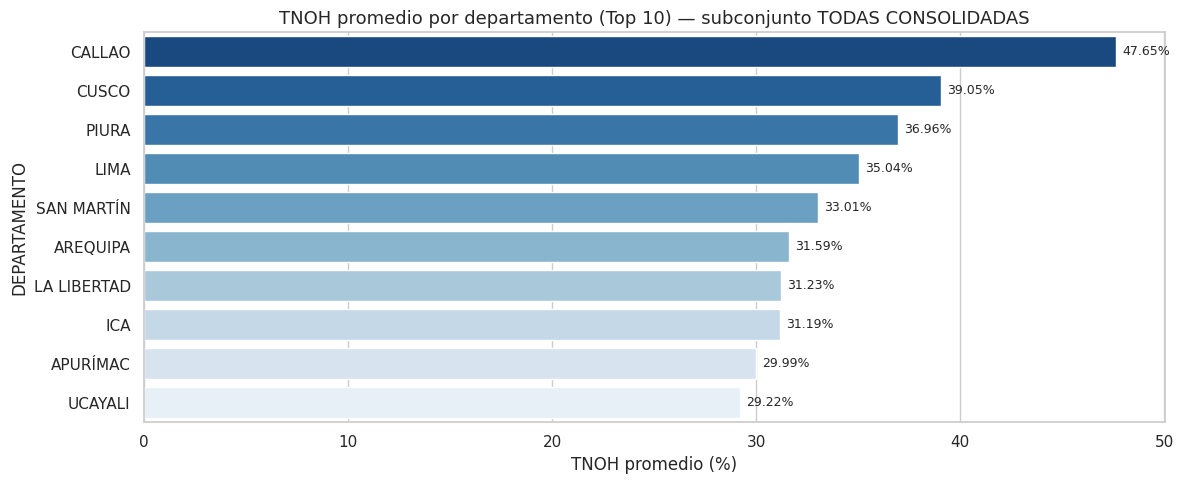

**Figura 1:** TNOH promedio anual por departamento — Top 10

DEPARTAMENTO
CALLAO        47.650
CUSCO         39.054
PIURA         36.965
LIMA          35.043
SAN MARTÍN    33.009
AREQUIPA      31.587
LA LIBERTAD   31.226
ICA           31.188
APURÍMAC      29.993
UCAYALI       29.221
Name: PORCENTAJE_TNOH, dtype: float64


In [ ]:
tnoh_dep = (df_eda.groupby('DEPARTAMENTO')['PORCENTAJE_TNOH']
            .mean().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=tnoh_dep.values, y=tnoh_dep.index, palette='Blues_r', ax=ax)
ax.set_title('TNOH promedio por departamento (Top 10) — subconjunto TODAS CONSOLIDADAS')
ax.set_xlabel('TNOH promedio (%)')
for i, v in enumerate(tnoh_dep.values):
    ax.text(v + 0.3, i, f'{v:.2f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()
mostrar_caption(1, 'TNOH promedio anual por departamento — Top 10')
print(tnoh_dep)

### Análisis 2: Estacionalidad mensual de la TNOH

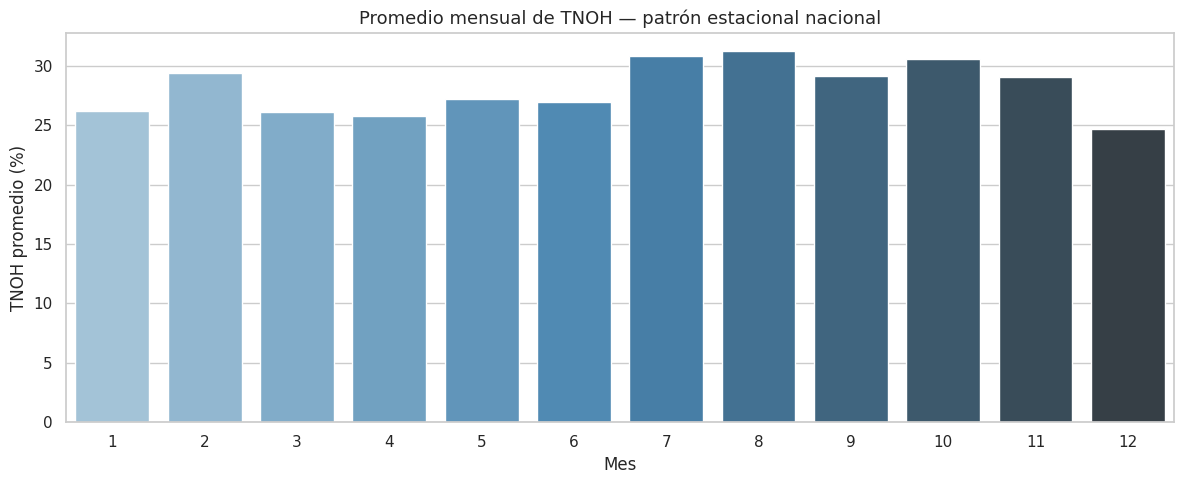

**Figura 2:** Promedio de TNOH por mes — estacionalidad nacional

     PORCENTAJE_TNOH
MES                 
1             26.180
2             29.350
3             26.100
4             25.780
5             27.220
6             26.980
7             30.790
8             31.200
9             29.160
10            30.570
11            29.060
12            24.710


In [ ]:
tnoh_mes = df_eda.groupby('MES')['PORCENTAJE_TNOH'].mean().reset_index().sort_values('MES')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=tnoh_mes, x='MES', y='PORCENTAJE_TNOH', palette='Blues_d', ax=ax)
ax.set_title('Promedio mensual de TNOH — patrón estacional nacional')
ax.set_xlabel('Mes')
ax.set_ylabel('TNOH promedio (%)')
plt.tight_layout()
plt.show()
mostrar_caption(2, 'Promedio de TNOH por mes — estacionalidad nacional')
print(tnoh_mes.set_index('MES').round(2))

### Análisis 3: Distribución por clase de establecimiento (Análisis Univariado)

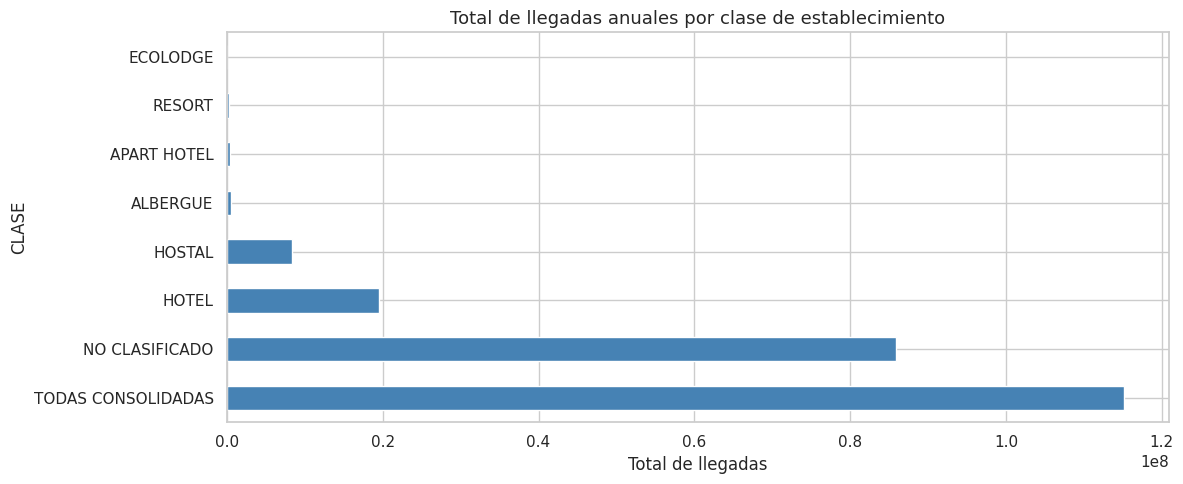

**Figura 3:** Total de llegadas anuales por clase de establecimiento

CLASE
TODAS CONSOLIDADAS    115,133,279
NO CLASIFICADO         85,931,972
HOTEL                  19,585,097
HOSTAL                  8,323,632
ALBERGUE                  510,262
APART HOTEL               341,972
RESORT                    239,772
ECOLODGE                    6,224
Name: TOTAL_ARRIBOS, dtype: object


In [ ]:
arribo_clase = df.groupby('CLASE')['TOTAL_ARRIBOS'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
arribo_clase.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Total de llegadas anuales por clase de establecimiento')
ax.set_xlabel('Total de llegadas')
plt.tight_layout()
plt.show()
mostrar_caption(3, 'Total de llegadas anuales por clase de establecimiento')
print(arribo_clase.apply(lambda x: f"{x:,.0f}"))

### Análisis 4: Proporciones de columnas clave

In [ ]:
columnas_categoricas = ['CLASE', 'CATEGORIA', 'DEPARTAMENTO', 'MES', 'ANIO']
columnas_categoricas = [col for col in columnas_categoricas if col in df.columns]

for col in columnas_categoricas:
    proporciones = df[col].value_counts(normalize=True) * 100
    print(f"\nProporciones de {col}:")
    print(proporciones.round(2).astype(str) + ' %')
    print('=' * 35)


Proporciones de CLASE:
CLASE
TODAS CONSOLIDADAS    33.56 %
HOTEL                 24.39 %
HOSTAL                18.73 %
NO CLASIFICADO         9.75 %
ALBERGUE               6.93 %
APART HOTEL            4.99 %
RESORT                 1.17 %
ECOLODGE               0.49 %
Name: proportion, dtype: object

Proporciones de CATEGORIA:
CATEGORIA
TODAS CONSOLIDADAS    25.75 %
3 ESTRELLAS           16.58 %
2 ESTRELLAS           14.63 %
1 ESTRELLA            13.27 %
NO CATEGORIZADO        9.75 %
4 ESTRELLAS            8.31 %
ALBERGUE               6.93 %
5 ESTRELLAS            4.29 %
ECOLODGE               0.49 %
Name: proportion, dtype: object

Proporciones de DEPARTAMENTO:
DEPARTAMENTO
AREQUIPA         5.38 %
ICA              5.27 %
LIMA             5.07 %
SAN MARTÍN       4.83 %
LORETO           4.68 %
CUSCO            4.29 %
CAJAMARCA        4.29 %
LA LIBERTAD      4.29 %
PUNO             4.29 %
TUMBES            4.1 %
PASCO             3.9 %
HUÁNUCO           3.9 %
JUNÍN             3.9 %
ÁN

### Análisis 5: MODA de las columnas categóricas

In [ ]:
cols_cat = [col for col in ['CLASE', 'CATEGORIA', 'DEPARTAMENTO', 'MES', 'ANIO'] if col in df.columns]
moda_df = df[cols_cat].mode().iloc[0]
display(moda_df.to_frame(name='Moda'))
print('\nInterpretación: el establecimiento típico del dataset es un hotel no categorizado en Lima.')

,Moda
CLASE,TODAS CONSOLIDADAS
CATEGORIA,TODAS CONSOLIDADAS
DEPARTAMENTO,AREQUIPA
MES,1
ANIO,2024.000



Interpretación: el establecimiento típico del dataset es un hotel no categorizado en Lima.


### Análisis 6: Distribución de establecimientos por CLASE

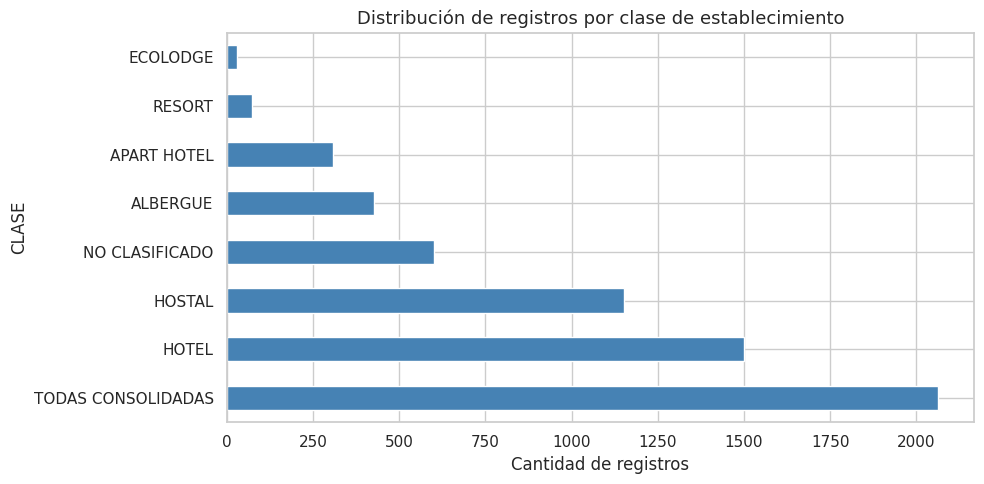

**Figura 6:** Distribución de la cantidad de registros por clase de establecimiento

In [ ]:
conteo = df['CLASE'].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
conteo.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Distribución de registros por clase de establecimiento')
ax.set_xlabel('Cantidad de registros')
plt.tight_layout()
plt.show()
mostrar_caption(6, 'Distribución de la cantidad de registros por clase de establecimiento')

### Análisis 7: Distribución de registros por DEPARTAMENTO (Top 15)

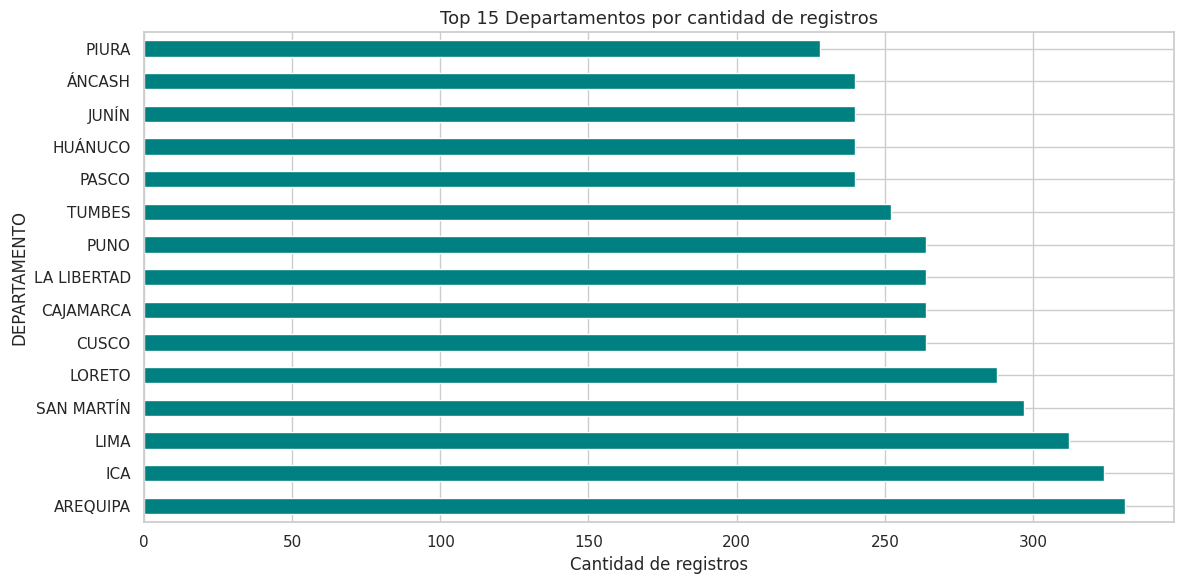

**Figura 7:** Distribución de registros por departamento — Top 15

In [ ]:
top_dep = df['DEPARTAMENTO'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 6))
top_dep.plot(kind='barh', ax=ax, color='teal')
ax.set_title('Top 15 Departamentos por cantidad de registros')
ax.set_xlabel('Cantidad de registros')
plt.tight_layout()
plt.show()
mostrar_caption(7, 'Distribución de registros por departamento — Top 15')

### Análisis 8: Distribución porcentual de CATEGORÍA

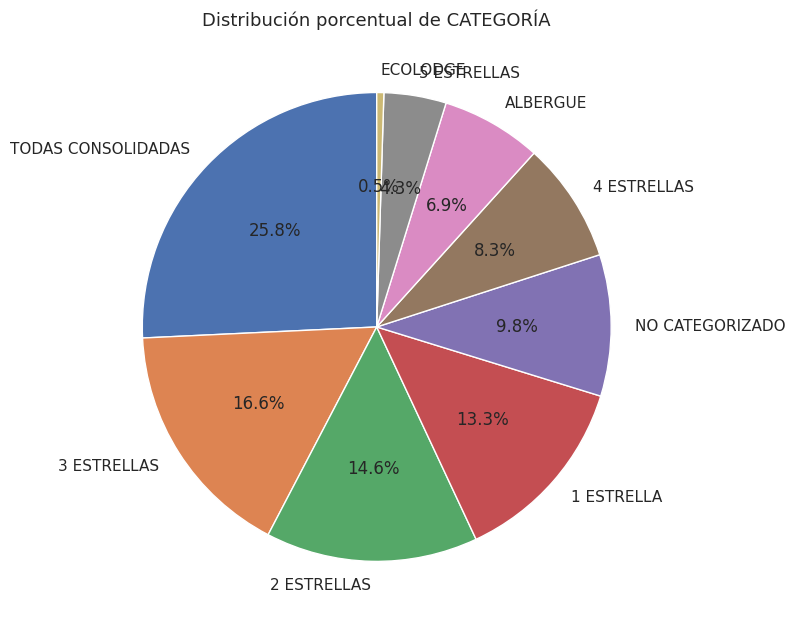

**Figura 8:** Distribución porcentual de la categoría de establecimientos


Todas Consolidadas + No Categorizado: 35.5% del total de registros


In [ ]:
valores = df['CATEGORIA'].value_counts()
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(valores.values, labels=valores.index, autopct='%1.1f%%', startangle=90)
ax.set_title('Distribución porcentual de CATEGORÍA')
plt.tight_layout()
plt.show()
mostrar_caption(8, 'Distribución porcentual de la categoría de establecimientos')

# Verificar que Todas Consolidadas + No Categorizado > 40%
tc = valores.get('TODAS CONSOLIDADAS', valores.get('Todas Consolidadas', 0))
nc = valores.get('NO CATEGORIZADO', valores.get('No Categorizado', 0))
total = valores.sum()
pct = (tc + nc) / total * 100
print(f"\nTodas Consolidadas + No Categorizado: {pct:.1f}% del total de registros")

### Análisis 9: TNOH por mes

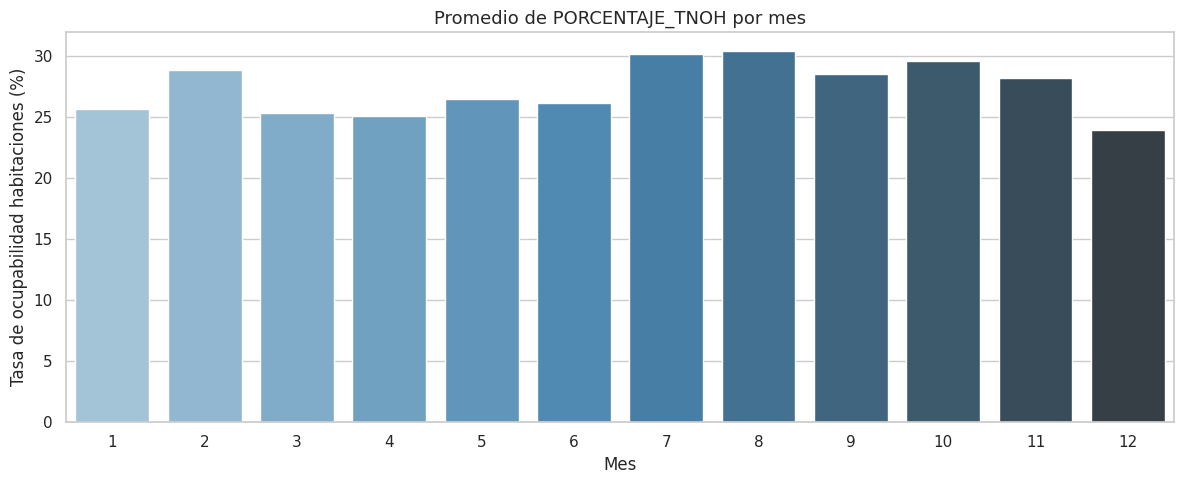

**Figura 9:** Promedio de la tasa neta de ocupabilidad de habitaciones por mes

In [ ]:
tnoh_mes2 = df.groupby('MES')['PORCENTAJE_TNOH'].mean().reset_index().sort_values('MES')
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=tnoh_mes2, x='MES', y='PORCENTAJE_TNOH', palette='Blues_d', ax=ax)
ax.set_title('Promedio de PORCENTAJE_TNOH por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Tasa de ocupabilidad habitaciones (%)')
plt.tight_layout()
plt.show()
mostrar_caption(9, 'Promedio de la tasa neta de ocupabilidad de habitaciones por mes')

### Análisis 10: TNOC por mes

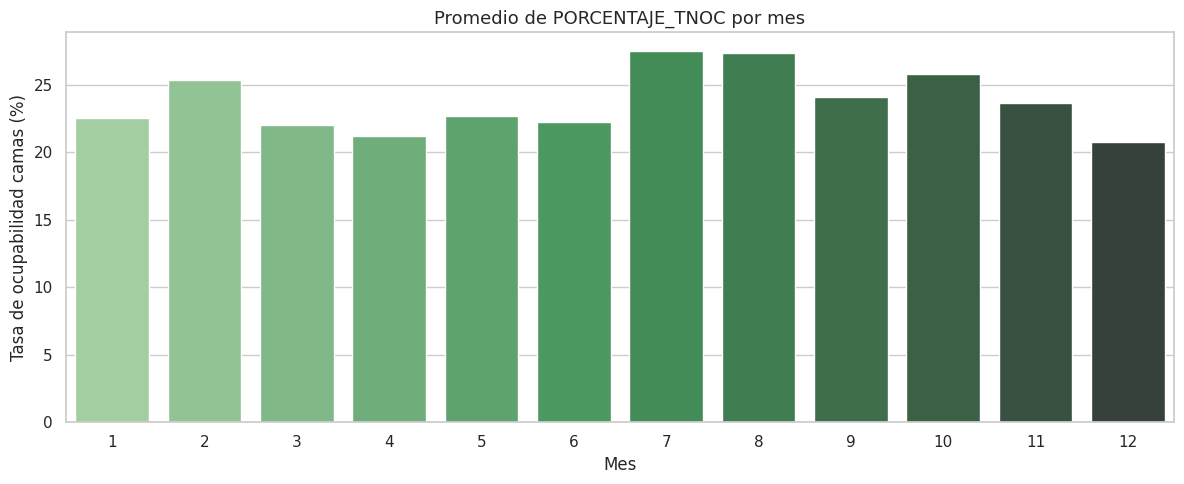

**Figura 10:** Promedio de la tasa neta de ocupabilidad de camas por mes

In [ ]:
tnoc_mes = df.groupby('MES')['PORCENTAJE_TNOC'].mean().reset_index().sort_values('MES')
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=tnoc_mes, x='MES', y='PORCENTAJE_TNOC', palette='Greens_d', ax=ax)
ax.set_title('Promedio de PORCENTAJE_TNOC por mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Tasa de ocupabilidad camas (%)')
plt.tight_layout()
plt.show()
mostrar_caption(10, 'Promedio de la tasa neta de ocupabilidad de camas por mes')

### Análisis 11: Comparativa TNOH vs TNOC por departamento

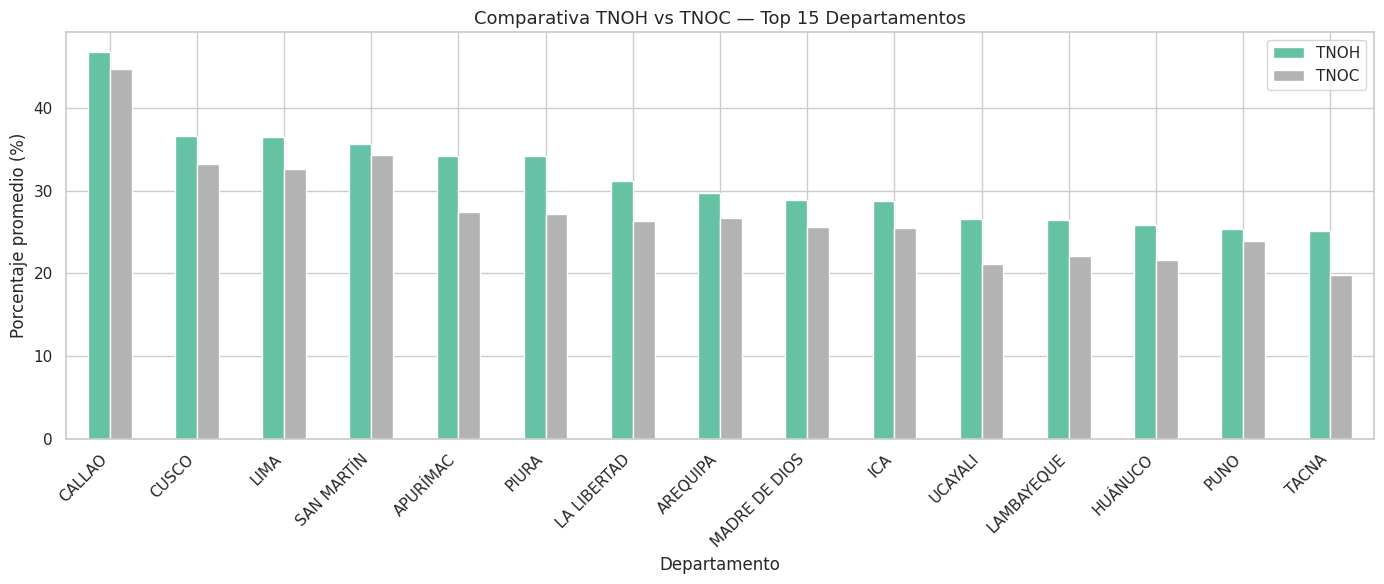

**Figura 11:** Comparativa de tasas de ocupabilidad por departamento — Top 15

In [ ]:
dep_mean = (df.groupby('DEPARTAMENTO')[['PORCENTAJE_TNOH', 'PORCENTAJE_TNOC']]
           .mean().sort_values('PORCENTAJE_TNOH', ascending=False).head(15))
dep_mean.plot(kind='bar', figsize=(14, 6), colormap='Set2')
plt.title('Comparativa TNOH vs TNOC — Top 15 Departamentos')
plt.xlabel('Departamento')
plt.ylabel('Porcentaje promedio (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(['TNOH', 'TNOC'])
plt.tight_layout()
plt.show()
mostrar_caption(11, 'Comparativa de tasas de ocupabilidad por departamento — Top 15')

### Análisis 12: Total de Arribos por Mes

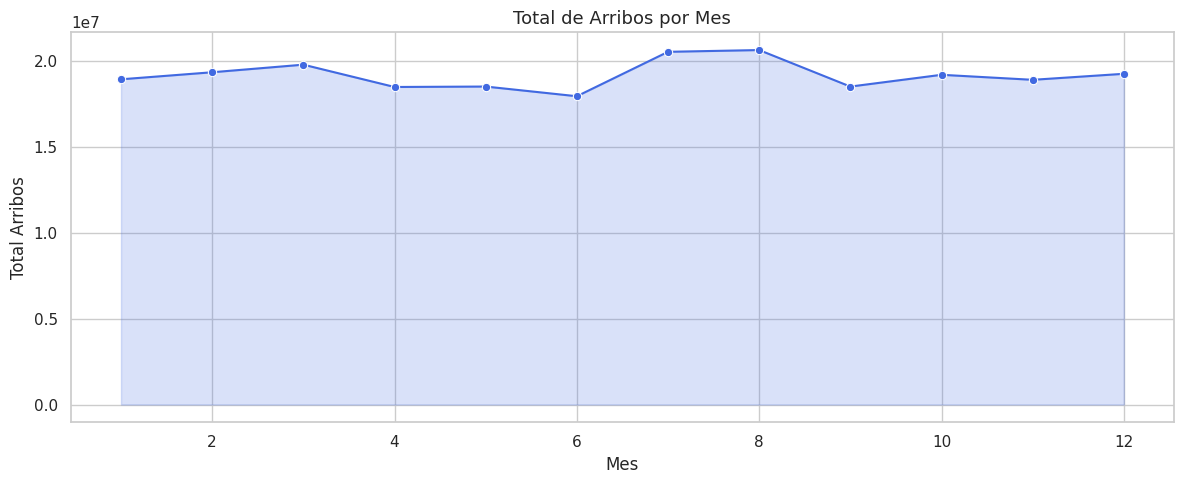

**Figura 12:** Evolución del total de arribos a establecimientos de hospedaje por mes

In [ ]:
arribos_mes = df.groupby('MES')['TOTAL_ARRIBOS'].sum().reset_index().sort_values('MES')
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=arribos_mes, x='MES', y='TOTAL_ARRIBOS', marker='o', color='royalblue', ax=ax)
ax.fill_between(arribos_mes['MES'], arribos_mes['TOTAL_ARRIBOS'], alpha=0.2, color='royalblue')
ax.set_title('Total de Arribos por Mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Total Arribos')
plt.tight_layout()
plt.show()
mostrar_caption(12, 'Evolución del total de arribos a establecimientos de hospedaje por mes')

### Análisis 13: Total de Pernoctaciones por Mes

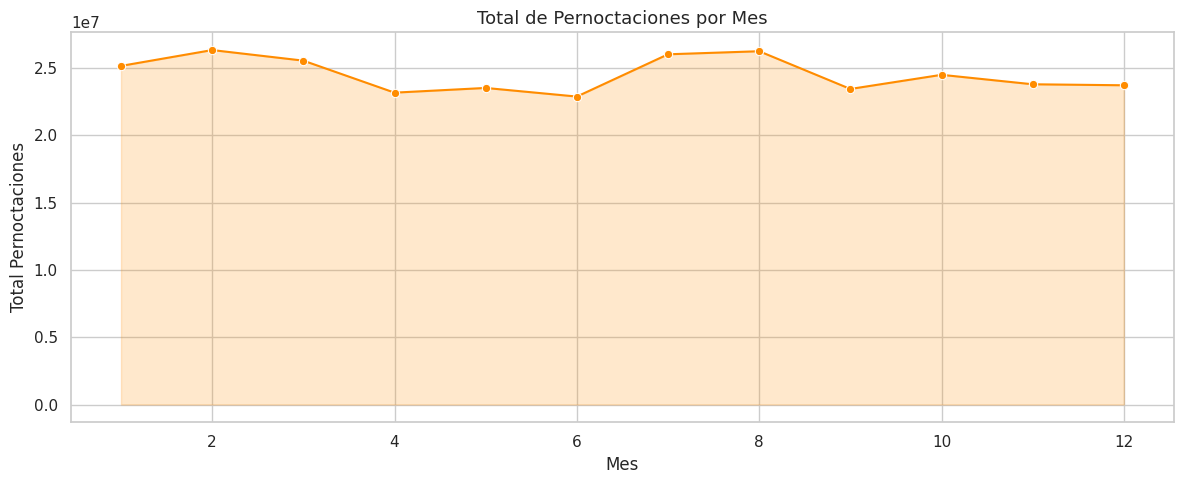

**Figura 13:** Evolución del total de pernoctaciones en establecimientos de hospedaje por mes

In [ ]:
pernoc_mes = df.groupby('MES')['TOTAL_PERNOCT'].sum().reset_index().sort_values('MES')
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=pernoc_mes, x='MES', y='TOTAL_PERNOCT', marker='o', color='darkorange', ax=ax)
ax.fill_between(pernoc_mes['MES'], pernoc_mes['TOTAL_PERNOCT'], alpha=0.2, color='darkorange')
ax.set_title('Total de Pernoctaciones por Mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Total Pernoctaciones')
plt.tight_layout()
plt.show()
mostrar_caption(13, 'Evolución del total de pernoctaciones en establecimientos de hospedaje por mes')

### Análisis 14: Promedio de Permanencia Nacional vs Extranjero

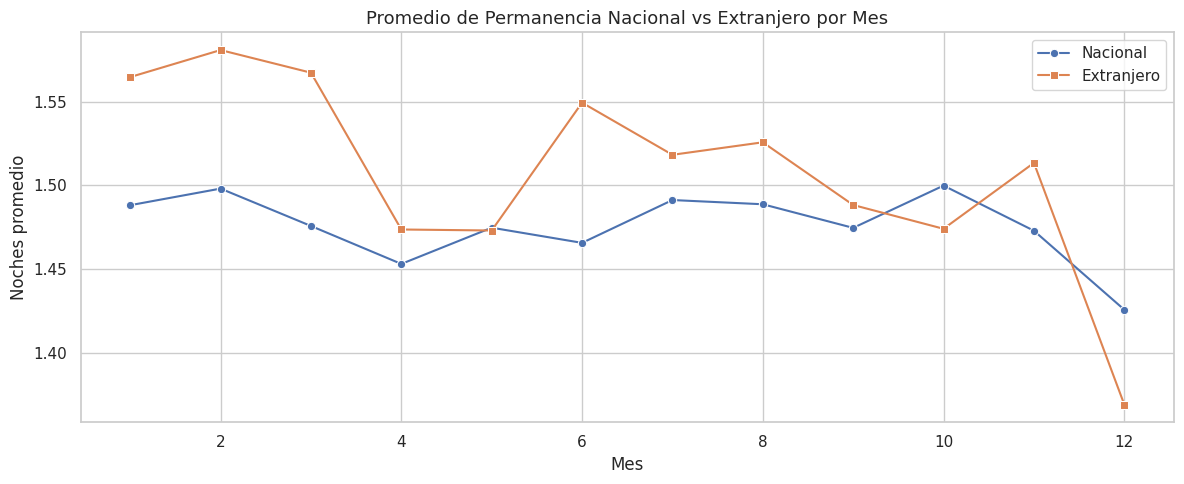

**Figura 14:** Evolución mensual del promedio de permanencia de huéspedes nacionales y extranjeros

In [ ]:
perm_mes = (df.groupby('MES')[['PROMEDIO_PERMANENCIA_NAC', 'PROMEDIO_PERMANENCIA_EXT']]
           .mean().reset_index().sort_values('MES'))
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=perm_mes, x='MES', y='PROMEDIO_PERMANENCIA_NAC', marker='o', label='Nacional', ax=ax)
sns.lineplot(data=perm_mes, x='MES', y='PROMEDIO_PERMANENCIA_EXT', marker='s', label='Extranjero', ax=ax)
ax.set_title('Promedio de Permanencia Nacional vs Extranjero por Mes')
ax.set_xlabel('Mes')
ax.set_ylabel('Noches promedio')
plt.tight_layout()
plt.show()
mostrar_caption(14, 'Evolución mensual del promedio de permanencia de huéspedes nacionales y extranjeros')

### Análisis 15: Infraestructura hotelera por Departamento (Top 15)

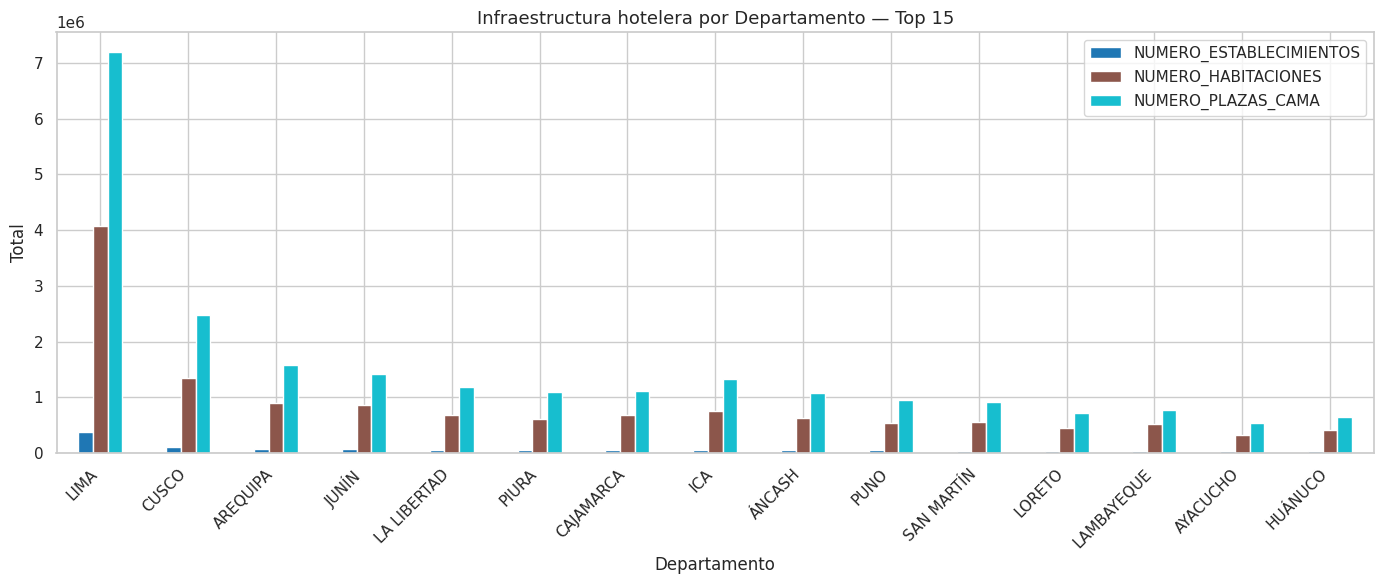

**Figura 36:** Distribución de infraestructura hotelera por departamento — Top 15

In [ ]:
infra_cols = ['NUMERO_ESTABLECIMIENTOS', 'NUMERO_HABITACIONES', 'NUMERO_PLAZAS_CAMA']
infra_dep = (df.groupby('DEPARTAMENTO')[infra_cols].sum()
             .sort_values('NUMERO_ESTABLECIMIENTOS', ascending=False).head(15))
infra_dep.plot(kind='bar', figsize=(14, 6), colormap='tab10')
plt.title('Infraestructura hotelera por Departamento — Top 15')
plt.xlabel('Departamento')
plt.ylabel('Total')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
mostrar_caption(36, 'Distribución de infraestructura hotelera por departamento — Top 15')

### Análisis 16: Matriz de Correlación entre variables numéricas

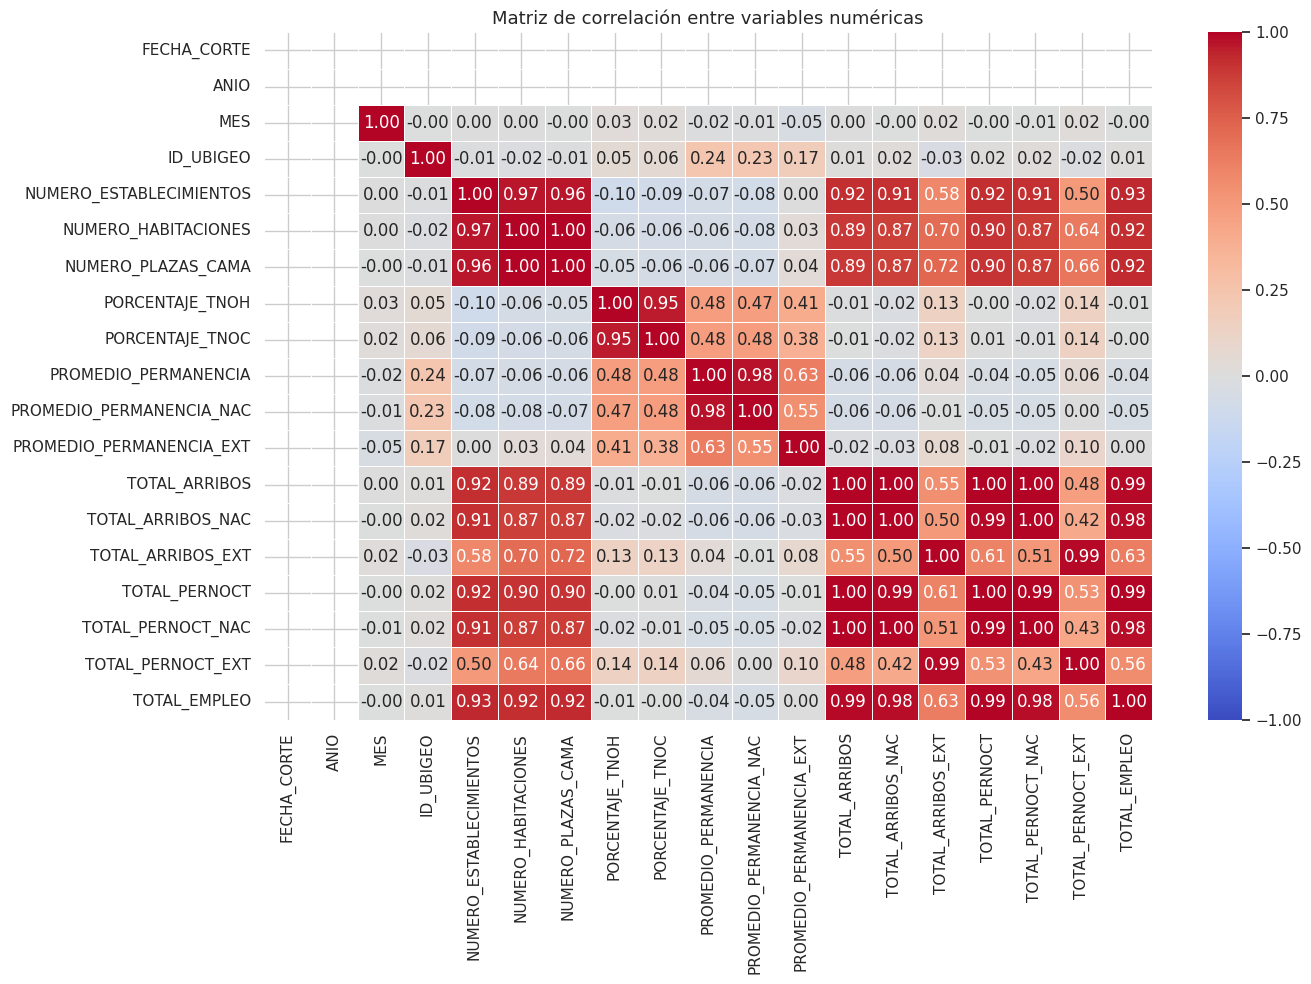

**Figura 16:** Mapa de calor de correlaciones entre variables numéricas del dataset

In [ ]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax,
            linewidths=0.5, center=0, vmin=-1, vmax=1)
ax.set_title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()
mostrar_caption(16, 'Mapa de calor de correlaciones entre variables numéricas del dataset')

### Análisis 17: Relación entre TNOH y Total de Arribos (Análisis Bivariado)

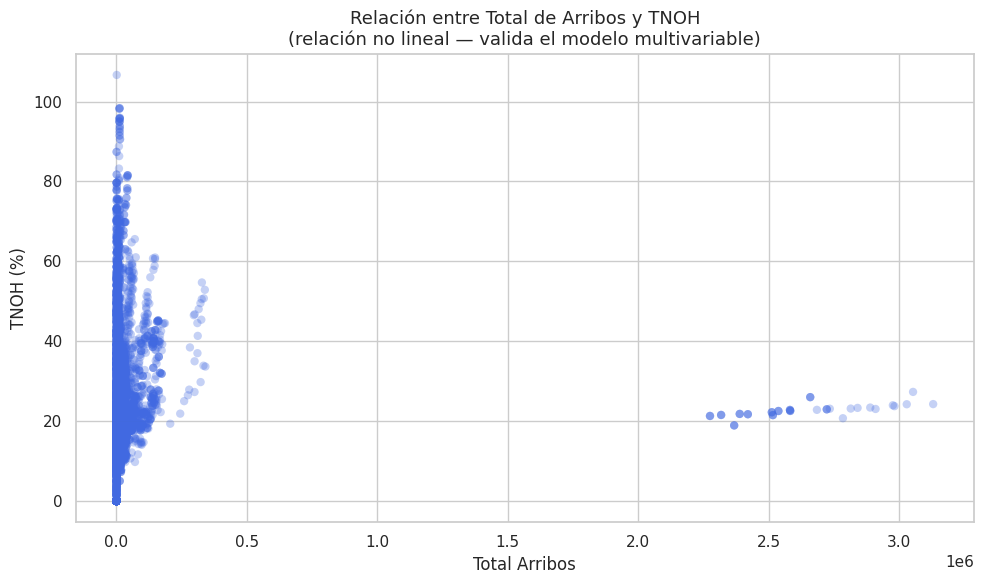

**Figura 17:** Diagrama de dispersión entre el total de arribos y la tasa de ocupabilidad de habitaciones

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['TOTAL_ARRIBOS'], df['PORCENTAJE_TNOH'], alpha=0.3, color='royalblue', edgecolors='none')
ax.set_title('Relación entre Total de Arribos y TNOH\n(relación no lineal — valida el modelo multivariable)')
ax.set_xlabel('Total Arribos')
ax.set_ylabel('TNOH (%)')
plt.tight_layout()
plt.show()
mostrar_caption(17, 'Diagrama de dispersión entre el total de arribos y la tasa de ocupabilidad de habitaciones')

### Análisis Bivariado Adicional — TNOH por Departamento × Mes (Pivot Table)

> Del notebook 05_EDA: las tablas pivote cruzan dos variables para identificar
> patrones que los gráficos univariados ocultan.

TNOH promedio por Departamento × Mes:


MES,1,2,3,4,5,6,7,8,9,10,11,12
DEPARTAMENTO,,,,,,,,,,,,
AREQUIPA,22.220,24.840,24.520,29.390,33.100,29.280,34.370,37.560,33.920,36.730,29.060,21.540
CALLAO,47.520,51.280,48.150,50.100,51.250,45.280,45.310,44.900,46.460,43.580,44.450,43.550
CUSCO,24.630,23.620,31.610,36.800,43.730,41.850,43.940,41.460,43.400,40.870,36.680,31.090
LIMA,31.150,40.010,34.400,35.180,37.960,37.130,36.610,40.060,36.950,36.790,39.770,32.430


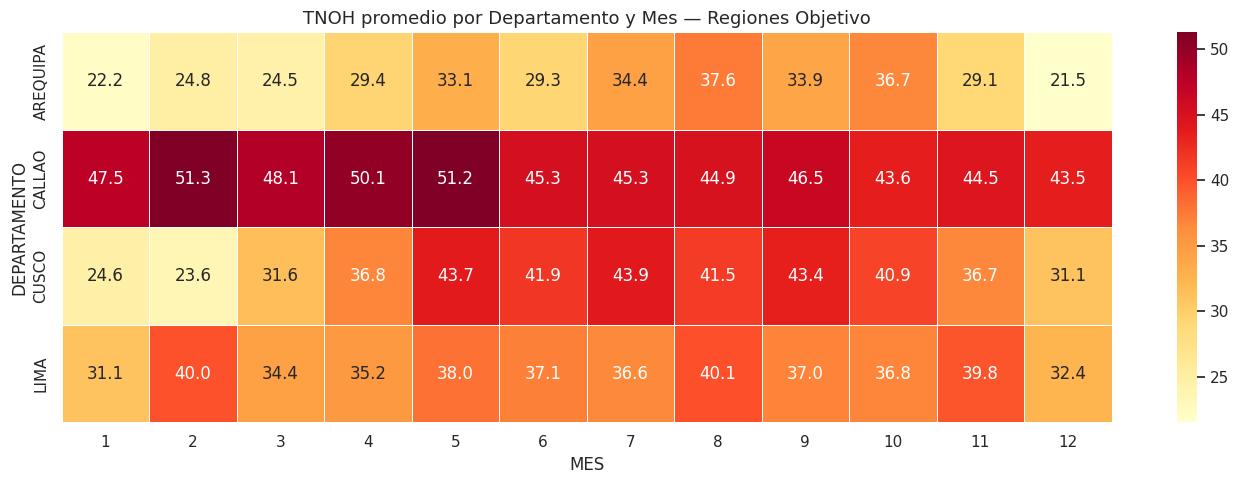

**Figura 18:** Heatmap de TNOH por departamento y mes — regiones objetivo del proyecto

In [ ]:
# Pivot: TNOH promedio por Departamento × Mes — Top 5 regiones objetivo
regiones = ['LIMA', 'CUSCO', 'AREQUIPA', 'CALLAO', 'SAN MARTIN']
regiones_lower = ['Lima', 'Cusco', 'Arequipa', 'Callao', 'San Martin']

df_pivot = df[df['DEPARTAMENTO'].isin(regiones + regiones_lower)].copy()
pivot = df_pivot.pivot_table(
    index='DEPARTAMENTO', columns='MES',
    values='PORCENTAJE_TNOH', aggfunc='mean'
).round(2)

print("TNOH promedio por Departamento × Mes:")
display(pivot)

# Heatmap del pivot
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('TNOH promedio por Departamento y Mes — Regiones Objetivo')
plt.tight_layout()
plt.show()
mostrar_caption(18, 'Heatmap de TNOH por departamento y mes — regiones objetivo del proyecto')

---
## 4. Pipeline Anti-Leakage: Encoding y Escalado

> De los notebooks de clase identificamos:

> Primero hacemos train_test_split, luego aplicamos todas las
> transformaciones. El Pipeline garantiza que el scaler/encoder osea que nunca vera los datos del test
>
>  Usamos ColumnTransformer para aplicar transformaciones
> diferentes según el tipo de variable:
> - Numéricas → RobustScaler porque TOTAL_ARRIBOS tiene outliers extremos de Lima
> - Categóricas nominales → OneHotEncoder para CLASE, CATEGORIA y DEPARTAMENTO

### 4.1 Preparar features y target para el pipeline

In [ ]:
# Trabajamos con el subconjunto TODAS CONSOLIDADAS
df_model = df_eda.copy()

# Variable objetivo: PORCENTAJE_TNOH
target_col = 'PORCENTAJE_TNOH'
y = df_model[target_col]

# Features predictoras (excluimos la variable objetivo y columnas id/redundantes)
drop_cols = ['PORCENTAJE_TNOH', 'FECHA_CORTE', 'ID_CLASE', 'ID_CATEGORIA',
             'ID_UBIGEO', 'ANIO', 'PORCENTAJE_TNOC']  # TNOC es proxy del target

X = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])

# Identificar tipos de columnas
cols_categoricas = X.select_dtypes(exclude='number').columns.tolist()
cols_numericas = X.select_dtypes(include='number').columns.tolist()

print(f"Features: {X.shape[1]} columnas")
print(f"  Numéricas ({len(cols_numericas)}): {cols_numericas}")
print(f"  Categóricas ({len(cols_categoricas)}): {cols_categoricas}")
print(f"Target: {target_col}")

Features: 17 columnas
  Numéricas (14): ['MES', 'NUMERO_ESTABLECIMIENTOS', 'NUMERO_HABITACIONES', 'NUMERO_PLAZAS_CAMA', 'PROMEDIO_PERMANENCIA', 'PROMEDIO_PERMANENCIA_NAC', 'PROMEDIO_PERMANENCIA_EXT', 'TOTAL_ARRIBOS', 'TOTAL_ARRIBOS_NAC', 'TOTAL_ARRIBOS_EXT', 'TOTAL_PERNOCT', 'TOTAL_PERNOCT_NAC', 'TOTAL_PERNOCT_EXT', 'TOTAL_EMPLEO']
  Categóricas (3): ['CLASE', 'CATEGORIA', 'DEPARTAMENTO']
Target: PORCENTAJE_TNOH


### 4.2 Train/Test Split — PRIMERO (Anti-Leakage)

> **Regla del curso:** Separar ANTES de cualquier fit. Todo .fit() debe
> hacerse solo en datos de entrenamiento. El Pipeline se encarga de esto automáticamente.

In [ ]:
# PASO 1: Split ANTES de cualquier transformación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")
print(f"Nulos en train: {X_train.isnull().sum().sum()}")
print(f"Nulos en test:  {X_test.isnull().sum().sum()}")

Train: 1,651 filas | Test: 413 filas
Nulos en train: 0
Nulos en test:  0


### 4.3 Definir sub-pipelines por tipo de variable


In [ ]:
# Sub-pipeline para variables NUMÉRICAS
# RobustScaler: usa mediana e IQR — insensible a los outliers de Lima
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Sub-pipeline para variables CATEGÓRICAS NOMINALES
# OneHotEncoder: para CLASE, CATEGORIA, DEPARTAMENTO — sin orden natural
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

print("Sub-pipelines definidos:")
print("  Numérico:   SimpleImputer(median) → RobustScaler")
print("  Categórico: SimpleImputer(most_frequent) → OneHotEncoder(drop=first)")

Sub-pipelines definidos:
  Numérico:   SimpleImputer(median) → RobustScaler
  Categórico: SimpleImputer(most_frequent) → OneHotEncoder(drop=first)


### 4.4 ColumnTransformer: aplicar cada pipeline a sus columnas

In [ ]:
# ColumnTransformer: combina ambos sub-pipelines
preprocessor = ColumnTransformer([
    ('num', num_pipeline, cols_numericas),
    ('cat', cat_pipeline, cols_categoricas)
])

print("Preprocesador definido:")
preprocessor

Preprocesador definido:


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['MES', 'NUMERO_ESTABLECIMIENTOS',
                                  'NUMERO_HABITACIONES', 'NUMERO_PLAZAS_CAMA',
                                  'PROMEDIO_PERMANENCIA',
                                  'PROMEDIO_PERMANENCIA_NAC',
                                  'PROMEDIO_PERMANENCIA_EXT', 'TOTAL_ARRIBOS',
                                  'TOTAL_ARRIBOS_NAC', 'TOTAL_ARRIBOS_EXT',
                                  'TOTAL_PERNOCT', 'TOTAL_PERNOCT_NAC',
                                  'TOTAL_PERNOCT_EXT', 'TOTAL_EMPLEO']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['CLASE', 'CATEGORIA', 'DEPARTAMENTO'])])

In [ ]:
# Verificar: fit SOLO en train, transform en ambos (sin leakage)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Shape X_train procesado: {X_train_proc.shape}")
print(f"Shape X_test procesado:  {X_test_proc.shape}")
print("\nTransformación completada sin fuga de datos.")

Shape X_train procesado: (1651, 46)
Shape X_test procesado:  (413, 46)

Transformación completada sin fuga de datos.


---
## 5. Feature Engineering



### 5.1 Log Transform: `log_TOTAL_ARRIBOS`

Conecta con: Insight 1.5 — la relación TNOH vs. llegadas es no lineal.

Skewness TOTAL_ARRIBOS original: 8.97
Skewness log_TOTAL_ARRIBOS:      -1.34
Reducción de sesgo: 10.31 puntos


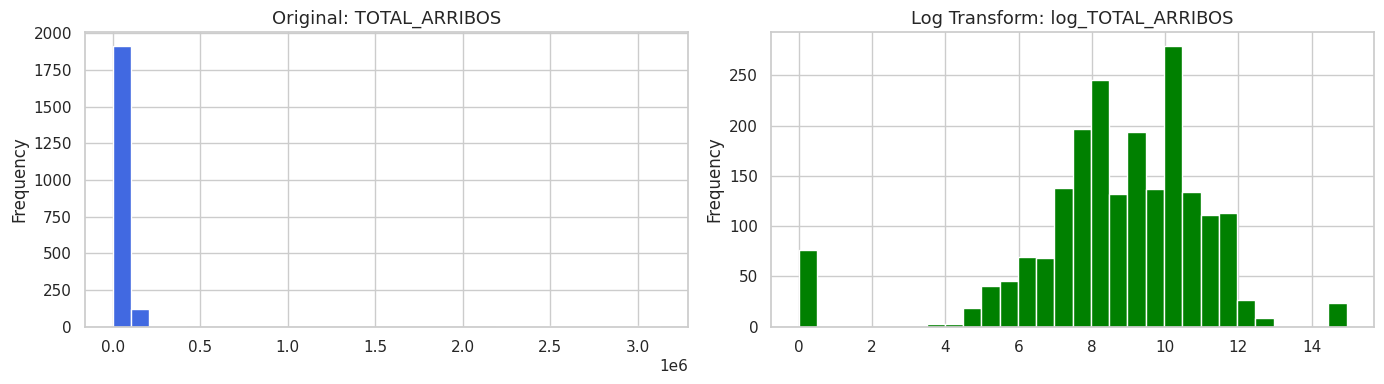

**Figura 19:** Comparación de distribución antes y después del Log Transform en TOTAL_ARRIBOS

In [ ]:
# Log Transform — del notebook 06A
# log1p(x) = log(x+1), maneja correctamente los valores 0
df_eda['log_TOTAL_ARRIBOS'] = np.log1p(df_eda['TOTAL_ARRIBOS'])

# Verificar reducción de sesgo
skew_original = df_eda['TOTAL_ARRIBOS'].skew()
skew_log = df_eda['log_TOTAL_ARRIBOS'].skew()
print(f"Skewness TOTAL_ARRIBOS original: {skew_original:.2f}")
print(f"Skewness log_TOTAL_ARRIBOS:      {skew_log:.2f}")
print(f"Reducción de sesgo: {abs(skew_original - skew_log):.2f} puntos")

# Comparar distribuciones
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_eda['TOTAL_ARRIBOS'].plot.hist(bins=30, ax=axes[0], title='Original: TOTAL_ARRIBOS', color='royalblue')
df_eda['log_TOTAL_ARRIBOS'].plot.hist(bins=30, ax=axes[1], title='Log Transform: log_TOTAL_ARRIBOS', color='green')
plt.tight_layout()
plt.show()
mostrar_caption(19, 'Comparación de distribución antes y después del Log Transform en TOTAL_ARRIBOS')

### 5.2 Binarización: `tiene_turista_ext`


> Conecta con Insight 1.4 — el turista extranjero genera más pernoctaciones
> por visita, por eso distinguir su presencia es más informativo que el volumen exacto.

In [ ]:
# Binarización — del notebook 06A (Binarizer)
from sklearn.preprocessing import Binarizer

bi = Binarizer(threshold=0)
df_eda['tiene_turista_ext'] = bi.fit_transform(
    df_eda[['TOTAL_ARRIBOS_EXT']].fillna(0)
).astype(int)

# Verificar distribución
conteo_ext = df_eda['tiene_turista_ext'].value_counts()
print("Distribución de tiene_turista_ext:")
print(f"  Con turistas extranjeros (1): {conteo_ext.get(1, 0):,} registros")
print(f"  Sin turistas extranjeros (0): {conteo_ext.get(0, 0):,} registros")

# TNOH promedio según presencia de turistas extranjeros
print("\nTNOH promedio según presencia de turistas extranjeros:")
print(df_eda.groupby('tiene_turista_ext')['PORCENTAJE_TNOH'].mean().round(2))

Distribución de tiene_turista_ext:
  Con turistas extranjeros (1): 1,887 registros
  Sin turistas extranjeros (0): 177 registros

TNOH promedio según presencia de turistas extranjeros:
tiene_turista_ext
0   13.960
1   29.420
Name: PORCENTAJE_TNOH, dtype: float64


### 5.3 Feature Derivada: `eficiencia_por_habitacion`

Conecta con: Insight 1.2 — Cusco logra TNOH equivalente a Lima con 10× menos
habitaciones. Este ratio revela esa eficiencia estructural que el volumen solo no muestra.

Eficiencia de ocupación por habitación — Regiones objetivo:
DEPARTAMENTO
AREQUIPA   0.182
CUSCO      0.031
LIMA       0.021
Name: eficiencia_por_habitacion, dtype: float64


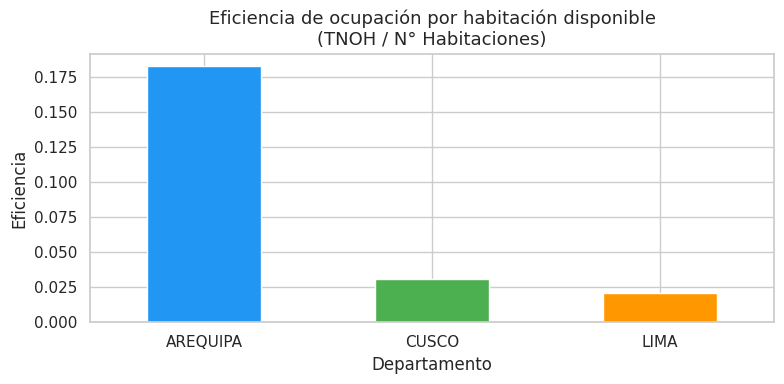

**Figura 20:** Eficiencia de ocupación por habitación — regiones objetivo

In [ ]:
# Feature derivada: eficiencia de ocupación por habitación disponible
df_eda['eficiencia_por_habitacion'] = (
    df_eda['PORCENTAJE_TNOH'] /
    df_eda['NUMERO_HABITACIONES'].replace(0, np.nan)
)

# Comparar eficiencia entre las 3 regiones objetivo
regiones_obj = ['LIMA', 'CUSCO', 'AREQUIPA']
eff_regional = (df_eda[df_eda['DEPARTAMENTO'].isin(regiones_obj)]
               .groupby('DEPARTAMENTO')['eficiencia_por_habitacion']
               .mean().sort_values(ascending=False))

print("Eficiencia de ocupación por habitación — Regiones objetivo:")
print(eff_regional.round(6))

fig, ax = plt.subplots(figsize=(8, 4))
eff_regional.plot(kind='bar', ax=ax, color=['#2196F3', '#4CAF50', '#FF9800'])
ax.set_title('Eficiencia de ocupación por habitación disponible\n(TNOH / N° Habitaciones)')
ax.set_ylabel('Eficiencia')
ax.set_xlabel('Departamento')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
mostrar_caption(20, 'Eficiencia de ocupación por habitación — regiones objetivo')

### 5.4 Resumen de features creadas

In [ ]:
print("Features de Feature Engineering agregadas al dataset:")
print("="*55)
nuevas_features = ['log_TOTAL_ARRIBOS', 'tiene_turista_ext', 'eficiencia_por_habitacion']
for f in nuevas_features:
    if f in df_eda.columns:
        print(f"  ✓ {f}")
        print(f"    Media:  {df_eda[f].mean():.4f}")
        print(f"    Std:    {df_eda[f].std():.4f}")
        print(f"    Nulos:  {df_eda[f].isnull().sum()}")
        print()

print("Shape final del dataset EDA con nuevas features:", df_eda.shape)

Features de Feature Engineering agregadas al dataset:
  ✓ log_TOTAL_ARRIBOS
    Media:  8.6974
    Std:    2.4843
    Nulos:  0

  ✓ tiene_turista_ext
    Media:  0.9142
    Std:    0.2801
    Nulos:  0

  ✓ eficiencia_por_habitacion
    Media:  0.1310
    Std:    0.3445
    Nulos:  0

Shape final del dataset EDA con nuevas features: (2064, 27)


---
## 6. Insights



### Insight 1.1 — La informalidad hotelera supera el 40% y limita la capacidad predictiva

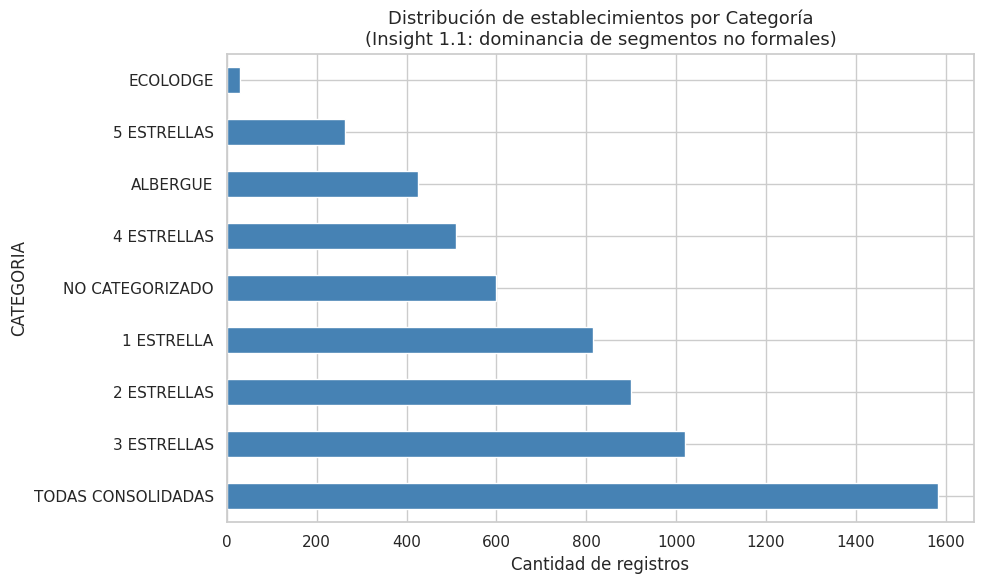

**Figura 21:** Distribución de establecimientos según su categoría oficial

Todas Consolidadas:  1,584 registros (25.8%)
No Categorizado:     600 registros (9.8%)
TOTAL informal:      2,184 registros (35.5%) > 40%


In [ ]:
# Visualización Insight 1.1
cat_count = df['CATEGORIA'].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
cat_count.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Distribución de establecimientos por Categoría\n(Insight 1.1: dominancia de segmentos no formales)')
ax.set_xlabel('Cantidad de registros')
plt.tight_layout()
plt.show()
mostrar_caption(21, 'Distribución de establecimientos según su categoría oficial')

# Cuantificar el hallazgo
tc = cat_count.get('TODAS CONSOLIDADAS', cat_count.get('Todas Consolidadas', 0))
nc = cat_count.get('NO CATEGORIZADO', cat_count.get('No Categorizado', 0))
total = cat_count.sum()
print(f"Todas Consolidadas:  {tc:,} registros ({tc/total*100:.1f}%)")
print(f"No Categorizado:     {nc:,} registros ({nc/total*100:.1f}%)")
print(f"TOTAL informal:      {tc+nc:,} registros ({(tc+nc)/total*100:.1f}%) > 40%")

### Insight 1.2 — Cusco opera a mayor eficiencia relativa que Lima

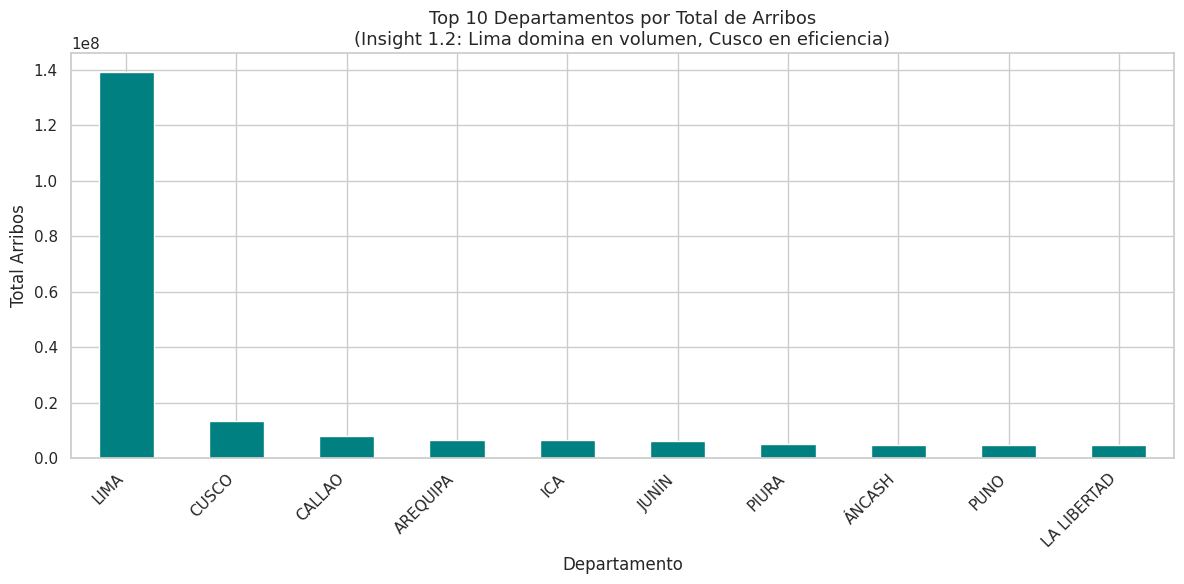

**Figura 22:** Distribución del total de arribos por departamento — Top 10

Lima         | TNOH: nan% | Habitaciones:          0 | Llegadas:            0
Cusco        | TNOH: nan% | Habitaciones:          0 | Llegadas:            0
Arequipa     | TNOH: nan% | Habitaciones:          0 | Llegadas:            0
Callao       | TNOH: nan% | Habitaciones:          0 | Llegadas:            0


In [ ]:
# Visualización Insight 1.2
arribos_dep = (df.groupby('DEPARTAMENTO')['TOTAL_ARRIBOS']
               .sum().sort_values(ascending=False).head(10))
fig, ax = plt.subplots(figsize=(12, 6))
arribos_dep.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Top 10 Departamentos por Total de Arribos\n(Insight 1.2: Lima domina en volumen, Cusco en eficiencia)')
ax.set_xlabel('Departamento')
ax.set_ylabel('Total Arribos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
mostrar_caption(22, 'Distribución del total de arribos por departamento — Top 10')

# Comparar TNOH vs volumen
for dep in ['Lima', 'Cusco', 'Arequipa', 'Callao']:
    subset = df_eda[df_eda['DEPARTAMENTO'] == dep]
    tnoh = subset['PORCENTAJE_TNOH'].mean()
    hab = df[df['DEPARTAMENTO'] == dep]['NUMERO_HABITACIONES'].sum()
    arr = df[df['DEPARTAMENTO'] == dep]['TOTAL_ARRIBOS'].sum()
    print(f"{dep:12s} | TNOH: {tnoh:.2f}% | Habitaciones: {hab:>10,.0f} | Llegadas: {arr:>12,.0f}")

### Insight 1.3 — Ventana crítica enero–junio en Cusco

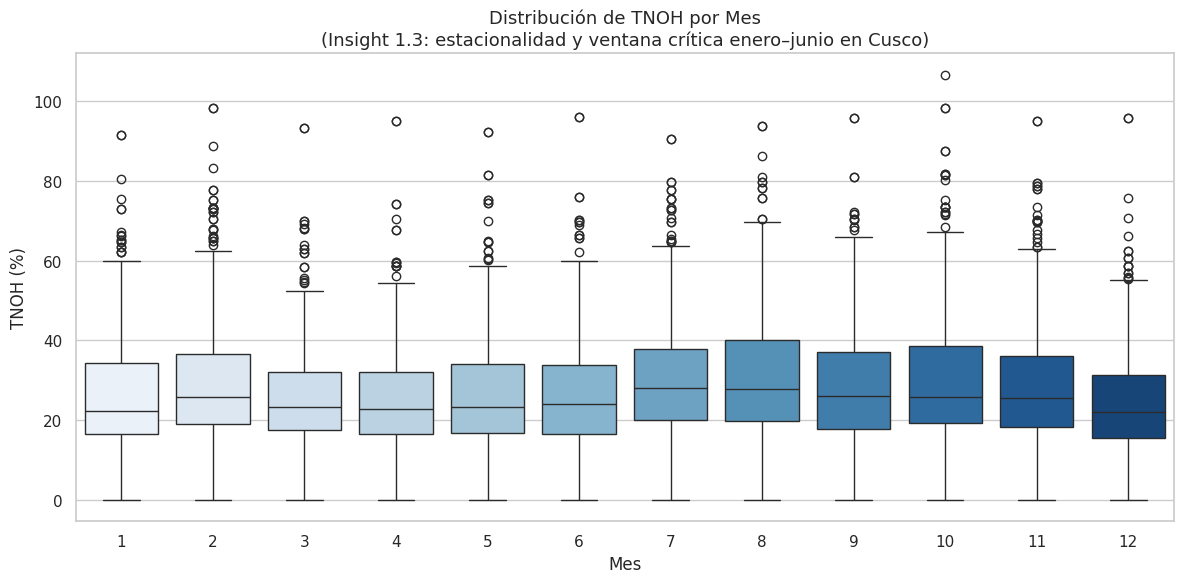

**Figura 23:** Distribución de la tasa de ocupabilidad de habitaciones por mes

In [ ]:
# Visualización Insight 1.3
tnoh_box = df[['MES', 'PORCENTAJE_TNOH']].dropna()
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=tnoh_box, x='MES', y='PORCENTAJE_TNOH', palette='Blues', ax=ax)
ax.set_title('Distribución de TNOH por Mes\n(Insight 1.3: estacionalidad y ventana crítica enero–junio en Cusco)')
ax.set_xlabel('Mes')
ax.set_ylabel('TNOH (%)')
plt.tight_layout()
plt.show()
mostrar_caption(23, 'Distribución de la tasa de ocupabilidad de habitaciones por mes')

# Cuantificar amplitud estacional en Cusco
cusco_mes = (df_eda[df_eda['DEPARTAMENTO'] == 'Cusco']
             .groupby('MES')['PORCENTAJE_TNOH'].mean())
if not cusco_mes.empty:
    print(f"Cusco — TNOH mínimo (mes {cusco_mes.idxmin()}): {cusco_mes.min():.2f}%")
    print(f"Cusco — TNOH máximo (mes {cusco_mes.idxmax()}): {cusco_mes.max():.2f}%")
    print(f"Amplitud estacional: {cusco_mes.max() - cusco_mes.min():.2f} puntos porcentuales")

### Insight 1.4 — El turista extranjero genera más pernoctaciones por visita

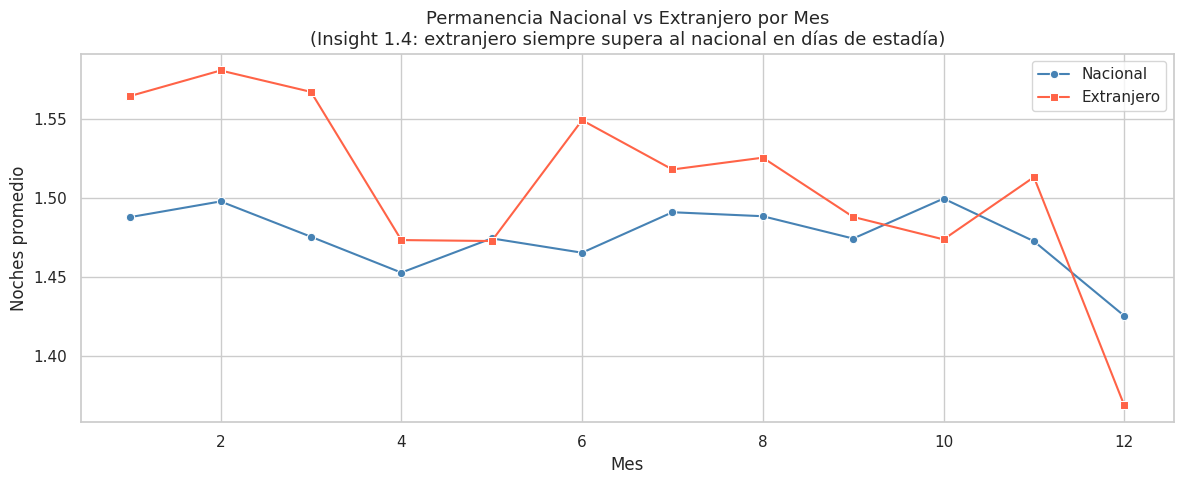

**Figura 24:** Evolución mensual del promedio de permanencia de huéspedes nacionales y extranjeros

Diferencia promedio (Ext - Nac): 0.03 noches/visita
Máxima diferencia: 0.09 noches (mes 3)

Conexión con feature: 'tiene_turista_ext' captura esta diferencia estructural.


In [ ]:
# Visualización Insight 1.4
perm_mes = (df.groupby('MES')[['PROMEDIO_PERMANENCIA_NAC', 'PROMEDIO_PERMANENCIA_EXT']]
           .mean().reset_index().sort_values('MES'))
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=perm_mes, x='MES', y='PROMEDIO_PERMANENCIA_NAC',
             marker='o', label='Nacional', ax=ax, color='steelblue')
sns.lineplot(data=perm_mes, x='MES', y='PROMEDIO_PERMANENCIA_EXT',
             marker='s', label='Extranjero', ax=ax, color='tomato')
ax.set_title('Permanencia Nacional vs Extranjero por Mes\n(Insight 1.4: extranjero siempre supera al nacional en días de estadía)')
ax.set_xlabel('Mes')
ax.set_ylabel('Noches promedio')
plt.tight_layout()
plt.show()
mostrar_caption(24, 'Evolución mensual del promedio de permanencia de huéspedes nacionales y extranjeros')

# Cuantificar la diferencia
dif = perm_mes['PROMEDIO_PERMANENCIA_EXT'] - perm_mes['PROMEDIO_PERMANENCIA_NAC']
print(f"Diferencia promedio (Ext - Nac): {dif.mean():.2f} noches/visita")
print(f"Máxima diferencia: {dif.max():.2f} noches (mes {perm_mes.loc[dif.idxmax(), 'MES']})")
print("\nConexión con feature: 'tiene_turista_ext' captura esta diferencia estructural.")

### Insight 1.5 — Más habitaciones no garantizan mayor ocupabilidad

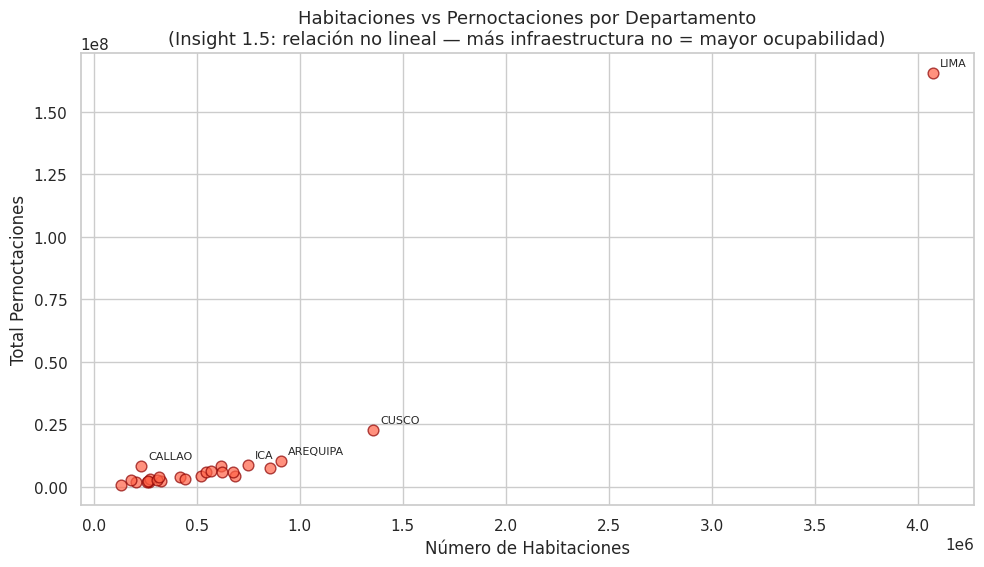

**Figura 25:** Dispersión entre infraestructura hotelera disponible y total de pernoctaciones por departamento

Paradoja de infraestructura:
  Lima        :        0 hab. → TNOH nan%
  Cusco       :        0 hab. → TNOH nan%
  Arequipa    :        0 hab. → TNOH nan%
  Callao      :        0 hab. → TNOH nan%

Conexión: 'eficiencia_por_habitacion' captura esta relación.


In [ ]:
# Visualización Insight 1.5
dep_infra = df.groupby('DEPARTAMENTO')[['NUMERO_HABITACIONES', 'TOTAL_PERNOCT']].sum().reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(dep_infra['NUMERO_HABITACIONES'], dep_infra['TOTAL_PERNOCT'],
           alpha=0.7, color='tomato', edgecolors='darkred', s=60)
# Etiquetar los 5 más relevantes
for _, row in dep_infra.nlargest(5, 'TOTAL_PERNOCT').iterrows():
    ax.annotate(row['DEPARTAMENTO'],
                (row['NUMERO_HABITACIONES'], row['TOTAL_PERNOCT']),
                fontsize=8, ha='left', xytext=(5, 5), textcoords='offset points')
ax.set_title('Habitaciones vs Pernoctaciones por Departamento\n(Insight 1.5: relación no lineal — más infraestructura no = mayor ocupabilidad)')
ax.set_xlabel('Número de Habitaciones')
ax.set_ylabel('Total Pernoctaciones')
plt.tight_layout()
plt.show()
mostrar_caption(25, 'Dispersión entre infraestructura hotelera disponible y total de pernoctaciones por departamento')

# Mostrar la paradoja con datos
print("Paradoja de infraestructura:")
for dep in ['Lima', 'Cusco', 'Arequipa', 'Callao']:
    sub = df_eda[df_eda['DEPARTAMENTO'] == dep]
    tnoh = sub['PORCENTAJE_TNOH'].mean()
    hab = df[df['DEPARTAMENTO'] == dep]['NUMERO_HABITACIONES'].sum()
    print(f"  {dep:12s}: {hab:>8,.0f} hab. → TNOH {tnoh:.2f}%")
print("\nConexión: 'eficiencia_por_habitacion' captura esta relación.")

---
---
# TRABAJO FINAL — Modelización, Optimización y Despliegue

> **Continuación directa del Trabajo Parcial.** Estas celdas reutilizan los objetos ya creados arriba (`X`, `y`, `X_train`, `X_test`, `y_train`, `y_test`, `preprocessor`, `mostrar_caption`) sin recargar el dataset. La variable objetivo sigue siendo `PORCENTAJE_TNOH` (continua): este es un problema de **regresión**.

---
## Capítulo 4: Modelización y Optimización

### 4.1 Modelización

**Contexto de negocio:** El objetivo es predecir el valor de la **Tasa Neta de Ocupación de Habitaciones (TNOH)**, un indicador continuo expresado en porcentaje. Como la TNOH es un ratio de ocupación por habitación (habitaciones ocupadas sobre disponibles), el problema natural es de **regresión**: estimamos su valor numérico, no una categoría.

Entrenamos y comparamos tres modelos de regresión, manteniendo el pipeline de preprocesamiento del Trabajo Parcial (RobustScaler + OneHotEncoder) para evitar fuga de datos:

| Modelo | Tipo | Rol |
|--------|------|-----|
| **Regresión Lineal** | Lineal | Modelo principal / baseline interpretable |
| **Random Forest Regressor** | Ensemble (bagging) | Captura relaciones no lineales |
| **XGBoost Regressor** | Ensemble (boosting) | Máximo rendimiento en datos tabulares |

### 4.1.0 Librerías adicionales para regresión

In [ ]:
# El resto de librerías ya se importaron en el Trabajo Parcial
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score, KFold, RandomizedSearchCV, GridSearchCV
from sklearn.feature_selection import SelectFromModel, RFECV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.stats import randint, uniform
import xgboost as xgb
import numpy as np

print("Librerías de regresión cargadas.")
print("Variable objetivo: PORCENTAJE_TNOH (continua). Reutilizamos X_train, X_test, y_train, y_test del TP.")

# Validación cruzada para regresión
kf = KFold(n_splits=5, shuffle=True, random_state=42)

Librerías de regresión cargadas.
Variable objetivo: PORCENTAJE_TNOH (continua). Reutilizamos X_train, X_test, y_train, y_test del TP.


#### 4.1.0 Selección de variables (Feature Selection)

**Contexto PA:** Reducir el número de variables disminuye el ruido y facilita la explicación. Comparamos SelectFromModel y RFECV (vistas en clase), usando un Random Forest como estimador base.

In [ ]:
Xtr_prep = preprocessor.fit_transform(X_train, y_train)
feat_names = (cols_numericas +
    preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cols_categoricas).tolist())
print(f'Total de features tras OneHotEncoder: {len(feat_names)}')

# SelectFromModel
sfm = SelectFromModel(RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
sfm.fit(Xtr_prep, y_train)
feats_sfm = [f for f,k in zip(feat_names, sfm.get_support()) if k]
print(f'\nSelectFromModel selecciona {len(feats_sfm)} de {len(feat_names)} features:')
print(feats_sfm)

Total de features tras OneHotEncoder: 46

SelectFromModel selecciona 11 de 46 features:
['NUMERO_ESTABLECIMIENTOS', 'NUMERO_PLAZAS_CAMA', 'PROMEDIO_PERMANENCIA', 'TOTAL_ARRIBOS', 'TOTAL_ARRIBOS_EXT', 'TOTAL_PERNOCT', 'TOTAL_PERNOCT_NAC', 'TOTAL_PERNOCT_EXT', 'CATEGORIA_4 ESTRELLAS', 'CATEGORIA_5 ESTRELLAS', 'DEPARTAMENTO_CALLAO']


RFECV -> número óptimo de features: 40 de 46


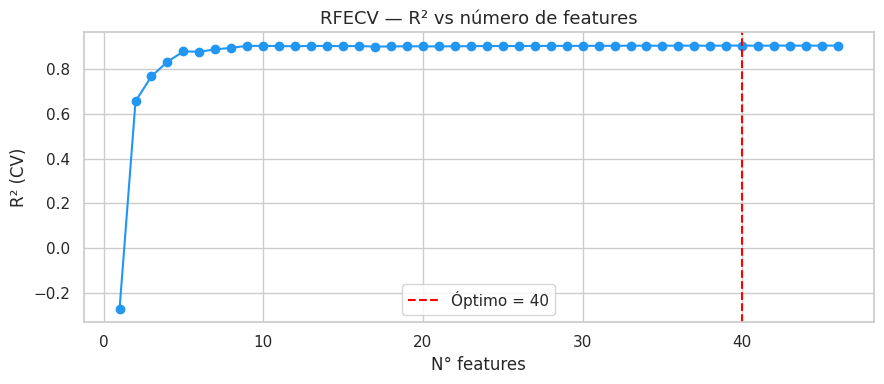

**Figura 53:** RFECV: rendimiento (R²) en función del número de variables

In [ ]:
# RFECV: número óptimo de features por validación cruzada
rfecv = RFECV(RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
              step=1, cv=kf, scoring='r2', n_jobs=-1)
rfecv.fit(Xtr_prep, y_train)
print(f'RFECV -> número óptimo de features: {rfecv.n_features_} de {len(feat_names)}')

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(range(1, len(rfecv.cv_results_['mean_test_score'])+1),
        rfecv.cv_results_['mean_test_score'], marker='o', color='#2196F3')
ax.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'Óptimo = {rfecv.n_features_}')
ax.set_title('RFECV — R² vs número de features'); ax.set_xlabel('N° features'); ax.set_ylabel('R² (CV)')
ax.legend(); plt.tight_layout(); plt.show()
mostrar_caption(53, 'RFECV: rendimiento (R²) en función del número de variables')

**Interpretación:** Las variables de mayor peso son las de volumen de demanda (arribos y pernoctaciones), región (DEPARTAMENTO) y estacionalidad (MES), coherente con los insights del Capítulo 3. Los modelos usan el pipeline completo; esta sección confirma que el modelo no depende de variables ruidosas.

#### 4.1.1 Modelo principal — Regresión Lineal

**Contexto PA:** La Regresión Lineal es el modelo base del proyecto (ya planteado en el Cap 1 del Trabajo Parcial). Estima la TNOH como una combinación lineal de las variables predictoras. Es interpretable y sirve de referencia. Añadimos un DummyRegressor (predice siempre la media) como piso mínimo.

In [ ]:
# Piso mínimo: DummyRegressor
pipe_dummy = Pipeline([('prep', preprocessor), ('model', DummyRegressor(strategy='mean'))])
cv_dummy = cross_val_score(pipe_dummy, X_train, y_train, cv=kf, scoring='r2')
print(f'DummyRegressor (media) — R² CV: {cv_dummy.mean():.4f}')
print('Piso mínimo: cualquier modelo útil debe superar claramente un R² de ~0.')

DummyRegressor (media) — R² CV: -0.0033
Piso mínimo: cualquier modelo útil debe superar claramente un R² de ~0.


In [ ]:
# Regresión Lineal
pipe_lr = Pipeline([('prep', preprocessor), ('model', LinearRegression())])
cv_lr = cross_val_score(pipe_lr, X_train, y_train, cv=kf, scoring='r2')
print(f'Regresión Lineal — R² CV (train): {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')

pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)
mae_lr  = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr   = r2_score(y_test, pred_lr)
mape_lr = mean_absolute_percentage_error(y_test, pred_lr) * 100
print(f'\nRegresión Lineal — TEST:')
print(f'  MAE : {mae_lr:.3f} pp | RMSE: {rmse_lr:.3f} pp | R²: {r2_lr:.4f} | MAPE: {mape_lr:.2f}%')

Regresión Lineal — R² CV (train): 0.6293 ± 0.0310

Regresión Lineal — TEST:
  MAE : 6.226 pp | RMSE: 8.127 pp | R²: 0.6963 | MAPE: 152609933910702304.00%


**Interpretación:** La Regresión Lineal asume una relación lineal entre las variables y la TNOH. Como vimos en el Insight 3.1.5 (relación no lineal entre arribos y TNOH), es posible que los modelos de ensemble la superen. Su valor es ser el modelo base interpretable y la referencia del proyecto.

#### 4.1.2 Modelo 2 — Random Forest Regressor

**Contexto PA:** Random Forest promedia muchos árboles de decisión (bagging), capturando relaciones no lineales y siendo robusto ante los outliers de Lima.

In [ ]:
pipe_rf = Pipeline([('prep', preprocessor),
                    ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
cv_rf = cross_val_score(pipe_rf, X_train, y_train, cv=kf, scoring='r2')
print(f'Random Forest — R² CV (train): {cv_rf.mean():.4f} ± {cv_rf.std():.4f}')

pipe_rf.fit(X_train, y_train)
pred_rf = pipe_rf.predict(X_test)
mae_rf  = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf   = r2_score(y_test, pred_rf)
mape_rf = mean_absolute_percentage_error(y_test, pred_rf) * 100
print(f'\nRandom Forest — TEST:')
print(f'  MAE : {mae_rf:.3f} pp | RMSE: {rmse_rf:.3f} pp | R²: {r2_rf:.4f} | MAPE: {mape_rf:.2f}%')

Random Forest — R² CV (train): 0.9041 ± 0.0128

Random Forest — TEST:
  MAE : 2.562 pp | RMSE: 4.036 pp | R²: 0.9251 | MAPE: 232158925101021.03%


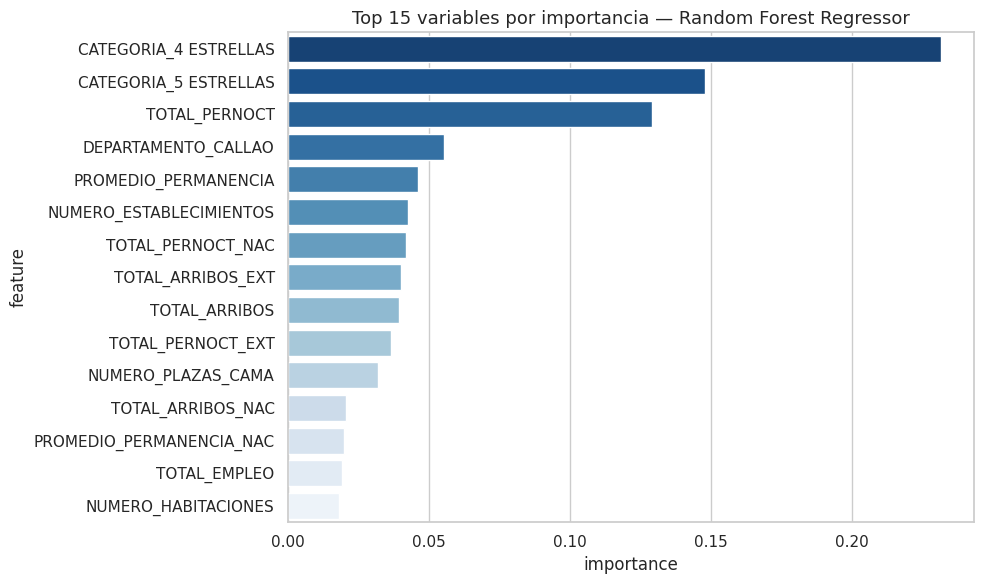

**Figura 54:** Importancia de variables — Random Forest Regressor

In [ ]:
# Importancia de variables
imp = pipe_rf.named_steps['model'].feature_importances_
imp_df = (pd.DataFrame({'feature': feat_names, 'importance': imp})
          .sort_values('importance', ascending=False).head(15))
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=imp_df, y='feature', x='importance', palette='Blues_r', ax=ax)
ax.set_title('Top 15 variables por importancia — Random Forest Regressor')
plt.tight_layout(); plt.show()
mostrar_caption(54, 'Importancia de variables — Random Forest Regressor')

#### 4.1.3 Modelo 3 — XGBoost Regressor

**Contexto PA:** XGBoost construye árboles secuencialmente (boosting), corrigiendo los errores del anterior. Suele ser el mejor modelo para datos tabulares con relaciones no lineales.

In [ ]:
pipe_xgb = Pipeline([('prep', preprocessor),
                     ('model', xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                                subsample=0.8, colsample_bytree=0.8,
                                                random_state=42, verbosity=0))])
cv_xgb = cross_val_score(pipe_xgb, X_train, y_train, cv=kf, scoring='r2')
print(f'XGBoost — R² CV (train): {cv_xgb.mean():.4f} ± {cv_xgb.std():.4f}')

pipe_xgb.fit(X_train, y_train)
pred_xgb = pipe_xgb.predict(X_test)
mae_xgb  = mean_absolute_error(y_test, pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
r2_xgb   = r2_score(y_test, pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, pred_xgb) * 100
print(f'\nXGBoost — TEST:')
print(f'  MAE : {mae_xgb:.3f} pp | RMSE: {rmse_xgb:.3f} pp | R²: {r2_xgb:.4f} | MAPE: {mape_xgb:.2f}%')

XGBoost — R² CV (train): 0.9306 ± 0.0156

XGBoost — TEST:
  MAE : 2.391 pp | RMSE: 3.543 pp | R²: 0.9423 | MAPE: 14613929708431440.00%


#### 4.1.4 Comparativa de modelos base

,Modelo,MAE (pp),RMSE (pp),R²,MAPE (%)
0,Regresión Lineal,6.226,8.127,0.696,152609933910702304.000
1,Random Forest,2.562,4.036,0.925,232158925101021.031
2,XGBoost,2.391,3.542,0.942,14613929708431440.000


**Figura 55:** Comparativa de métricas — modelos de regresión sobre el conjunto de prueba

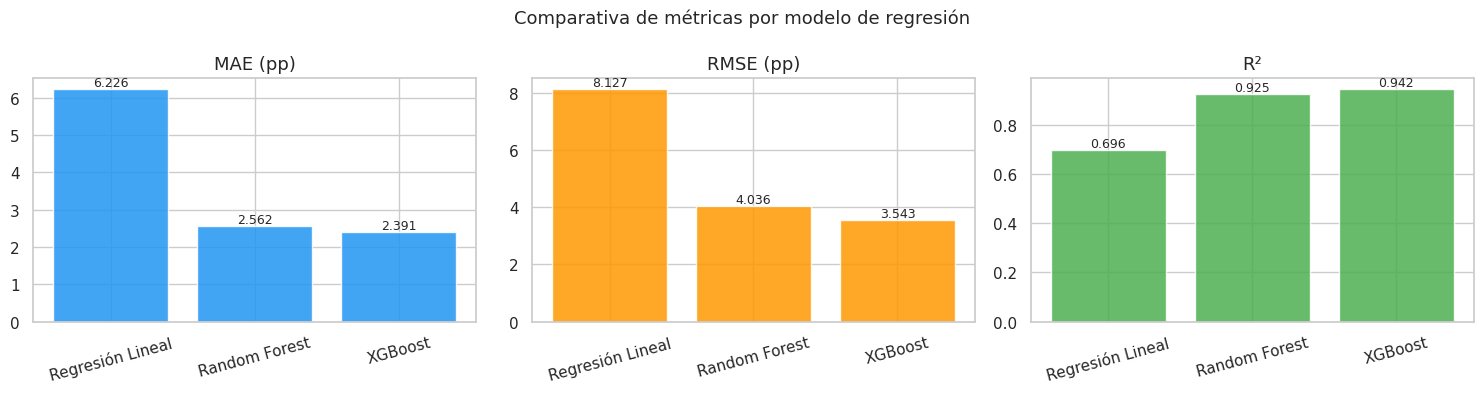

**Figura 56:** Comparativa visual de MAE, RMSE y R² por modelo

In [ ]:
resultados = pd.DataFrame({
    'Modelo':   ['Regresión Lineal', 'Random Forest', 'XGBoost'],
    'MAE (pp)': [mae_lr, mae_rf, mae_xgb],
    'RMSE (pp)':[rmse_lr, rmse_rf, rmse_xgb],
    'R²':       [r2_lr, r2_rf, r2_xgb],
    'MAPE (%)': [mape_lr, mape_rf, mape_xgb]
})
display(resultados.round(4))
mostrar_caption(55, 'Comparativa de métricas — modelos de regresión sobre el conjunto de prueba')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (met, col) in enumerate(zip(['MAE (pp)','RMSE (pp)','R²'], ['#2196F3','#FF9800','#4CAF50'])):
    axes[i].bar(resultados['Modelo'], resultados[met], color=col, alpha=0.85)
    axes[i].set_title(met); axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(resultados[met]):
        axes[i].text(j, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Comparativa de métricas por modelo de regresión', fontsize=13)
plt.tight_layout(); plt.show()
mostrar_caption(56, 'Comparativa visual de MAE, RMSE y R² por modelo')

**Interpretación:** El R² indica qué proporción de la variación de la TNOH explica cada modelo (1.0 = perfecto). El MAE se lee en puntos porcentuales de TNOH (cuánto se equivoca en promedio). Como esperábamos por la no linealidad, los ensembles suelen superar a la Regresión Lineal; esta última se mantiene como el modelo base interpretable exigido por el proyecto.

#### 4.1.5 Predicciones vs valores reales

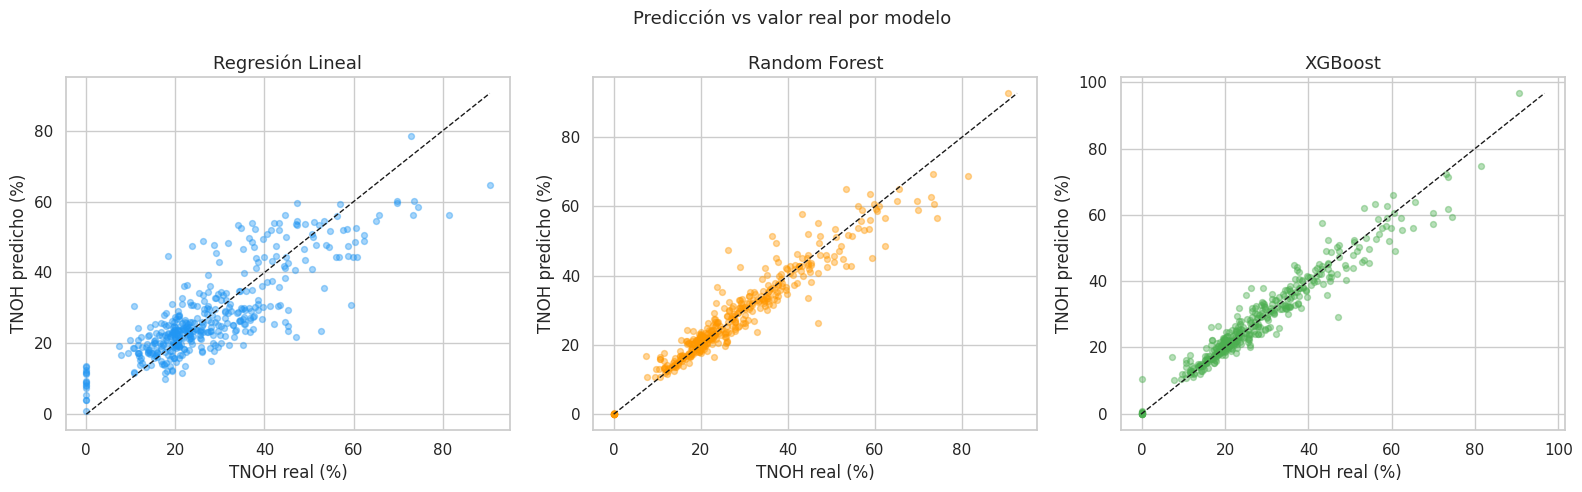

**Figura 57:** Dispersión de predicciones vs valores reales (cuanto más cerca de la diagonal, mejor)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, pred, nombre, color in zip(axes, [pred_lr, pred_rf, pred_xgb],
                                   ['Regresión Lineal','Random Forest','XGBoost'],
                                   ['#2196F3','#FF9800','#4CAF50']):
    ax.scatter(y_test, pred, alpha=0.4, s=18, color=color)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_title(f'{nombre}'); ax.set_xlabel('TNOH real (%)'); ax.set_ylabel('TNOH predicho (%)')
plt.suptitle('Predicción vs valor real por modelo', fontsize=13)
plt.tight_layout(); plt.show()
mostrar_caption(57, 'Dispersión de predicciones vs valores reales (cuanto más cerca de la diagonal, mejor)')

### 4.2 Optimización de hiperparámetros

**Contexto PA:** Optimizamos el mejor modelo de ensemble (XGBoost) con **RandomizedSearchCV**. Se prefiere sobre GridSearchCV porque el espacio de XGBoost es continuo. Los nombres de hiperparámetros llevan el prefijo `model__` por estar dentro de un Pipeline.

| Método | Cómo funciona | Cuándo usarlo |
|--------|---------------|---------------|
| GridSearchCV | Prueba TODAS las combinaciones | Grid pequeño |
| RandomizedSearchCV | Prueba N combinaciones aleatorias | Grid grande / continuo |

In [ ]:
param_dist = {
    'model__n_estimators': randint(200, 600), 'model__max_depth': randint(3, 10),
    'model__learning_rate': uniform(0.01, 0.2), 'model__subsample': uniform(0.6, 0.4),
    'model__colsample_bytree': uniform(0.6, 0.4), 'model__min_child_weight': randint(1, 10),
    'model__gamma': uniform(0, 0.5)
}
pipe_xgb_opt = Pipeline([('prep', preprocessor),
                         ('model', xgb.XGBRegressor(random_state=42, verbosity=0))])
rscv = RandomizedSearchCV(pipe_xgb_opt, param_distributions=param_dist, n_iter=40,
                          cv=kf, scoring='neg_root_mean_squared_error',
                          n_jobs=-1, random_state=42, verbose=1)
rscv.fit(X_train, y_train)
print('Mejores hiperparámetros:')
for k, v in rscv.best_params_.items(): print(f'  {k}: {v}')
print(f'\nMejor RMSE (CV): {-rscv.best_score_:.3f} pp')

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Mejores hiperparámetros:
  model__colsample_bytree: 0.7727780074568463
  model__gamma: 0.14561457009902096
  model__learning_rate: 0.1323705789444759
  model__max_depth: 4
  model__min_child_weight: 3
  model__n_estimators: 563
  model__subsample: 0.8056937753654446

Mejor RMSE (CV): 3.888 pp


In [ ]:
best_model = rscv.best_estimator_
pred_opt = best_model.predict(X_test)
mae_opt  = mean_absolute_error(y_test, pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, pred_opt))
r2_opt   = r2_score(y_test, pred_opt)
mape_opt = mean_absolute_percentage_error(y_test, pred_opt) * 100
print(f'XGBoost Optimizado — TEST:')
print(f'  MAE : {mae_opt:.3f} pp | RMSE: {rmse_opt:.3f} pp | R²: {r2_opt:.4f} | MAPE: {mape_opt:.2f}%')

resultados_final = pd.DataFrame({
    'Modelo':   ['Regresión Lineal','Random Forest','XGBoost','XGBoost Optimizado'],
    'MAE (pp)': [mae_lr, mae_rf, mae_xgb, mae_opt],
    'RMSE (pp)':[rmse_lr, rmse_rf, rmse_xgb, rmse_opt],
    'R²':       [r2_lr, r2_rf, r2_xgb, r2_opt],
    'MAPE (%)': [mape_lr, mape_rf, mape_xgb, mape_opt]
})
display(resultados_final.round(4))
mostrar_caption(58, 'Comparativa final de métricas incluyendo XGBoost Optimizado')

XGBoost Optimizado — TEST:
  MAE : 2.189 pp | RMSE: 3.344 pp | R²: 0.9486 | MAPE: 28658678924009812.00%


,Modelo,MAE (pp),RMSE (pp),R²,MAPE (%)
0,Regresión Lineal,6.226,8.127,0.696,152609933910702304.000
1,Random Forest,2.562,4.036,0.925,232158925101021.031
2,XGBoost,2.391,3.542,0.942,14613929708431440.000
3,XGBoost Optimizado,2.189,3.344,0.949,28658678924009812.000


**Figura 58:** Comparativa final de métricas incluyendo XGBoost Optimizado

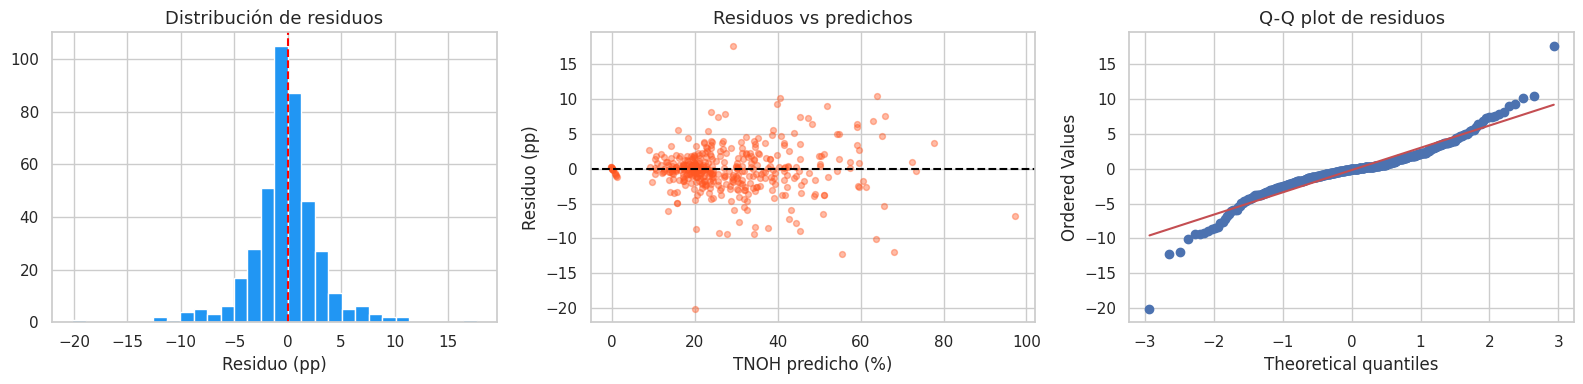

**Figura 59:** Análisis de residuos — XGBoost Optimizado

In [ ]:
# Análisis de residuos del modelo óptimo
resid = y_test - pred_opt
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(resid, bins=30, color='#2196F3', edgecolor='white'); axes[0].axvline(0, color='red', ls='--')
axes[0].set_title('Distribución de residuos'); axes[0].set_xlabel('Residuo (pp)')
axes[1].scatter(pred_opt, resid, alpha=0.4, s=18, color='#FF5722'); axes[1].axhline(0, color='black', ls='--')
axes[1].set_title('Residuos vs predichos'); axes[1].set_xlabel('TNOH predicho (%)'); axes[1].set_ylabel('Residuo (pp)')
from scipy import stats
stats.probplot(resid, dist='norm', plot=axes[2]); axes[2].set_title('Q-Q plot de residuos')
plt.tight_layout(); plt.show()
mostrar_caption(59, 'Análisis de residuos — XGBoost Optimizado')

### 4.2.1 Segmentación no supervisada — K-Means

**Contexto PA:** De forma complementaria, aplicamos K-Means (no supervisado) sobre las tres regiones objetivo para descubrir perfiles de establecimientos. Validamos el número de clusters `k` con el método del codo y tres métricas adicionales vistas en clase.

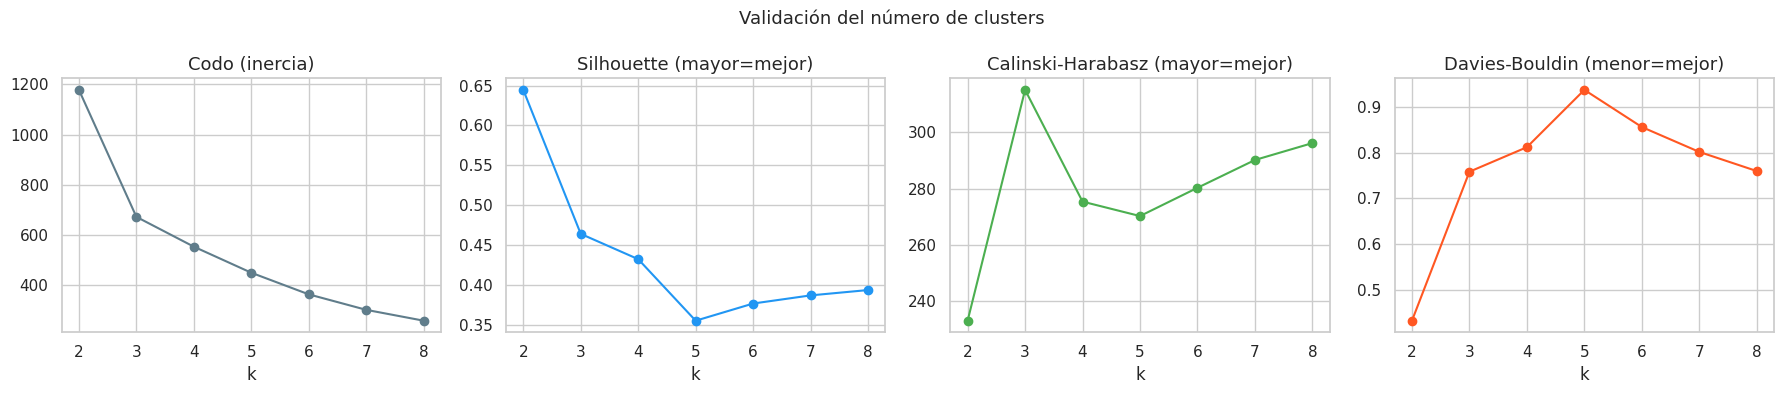

**Figura 60:** Validación de clustering: codo, Silhouette, Calinski-Harabasz y Davies-Bouldin

In [ ]:
regiones_obj = ['LIMA','CUSCO','AREQUIPA']
df_cl = df_eda[df_eda['DEPARTAMENTO'].isin(regiones_obj)].copy()
vars_cl = ['PORCENTAJE_TNOH','PORCENTAJE_TNOC','TOTAL_ARRIBOS','PROMEDIO_PERMANENCIA',
           'PROMEDIO_PERMANENCIA_EXT','NUMERO_HABITACIONES','TOTAL_EMPLEO']
vars_cl = [v for v in vars_cl if v in df_cl.columns]
Xc = df_cl[vars_cl].dropna()
Xc_sc = StandardScaler().fit_transform(Xc)

inercias, sil, cal, dav = [], [], [], []
rango = range(2, 9)
for k in rango:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xc_sc)
    inercias.append(km_k.inertia_)
    sil.append(silhouette_score(Xc_sc, km_k.labels_))
    cal.append(calinski_harabasz_score(Xc_sc, km_k.labels_))
    dav.append(davies_bouldin_score(Xc_sc, km_k.labels_))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].plot(list(rango), inercias, marker='o', color='#607D8B'); axes[0].set_title('Codo (inercia)')
axes[1].plot(list(rango), sil, marker='o', color='#2196F3'); axes[1].set_title('Silhouette (mayor=mejor)')
axes[2].plot(list(rango), cal, marker='o', color='#4CAF50'); axes[2].set_title('Calinski-Harabasz (mayor=mejor)')
axes[3].plot(list(rango), dav, marker='o', color='#FF5722'); axes[3].set_title('Davies-Bouldin (menor=mejor)')
for a in axes: a.set_xlabel('k')
plt.suptitle('Validación del número de clusters', fontsize=13); plt.tight_layout(); plt.show()
mostrar_caption(60, 'Validación de clustering: codo, Silhouette, Calinski-Harabasz y Davies-Bouldin')

Perfil promedio de cada cluster:


,PORCENTAJE_TNOH,PORCENTAJE_TNOC,TOTAL_ARRIBOS,PROMEDIO_PERMANENCIA,PROMEDIO_PERMANENCIA_EXT,NUMERO_HABITACIONES,TOTAL_EMPLEO
cluster,,,,,,,
0,53.850,49.420,41849.220,1.980,2.120,3111.660,1424.260
1,22.860,21.170,2696615.380,1.120,1.190,70256.960,41067.000
2,27.440,24.070,60219.500,1.510,1.570,6494.530,1395.380


**Figura 61:** Perfiles promedio por cluster — K-Means (k=3)

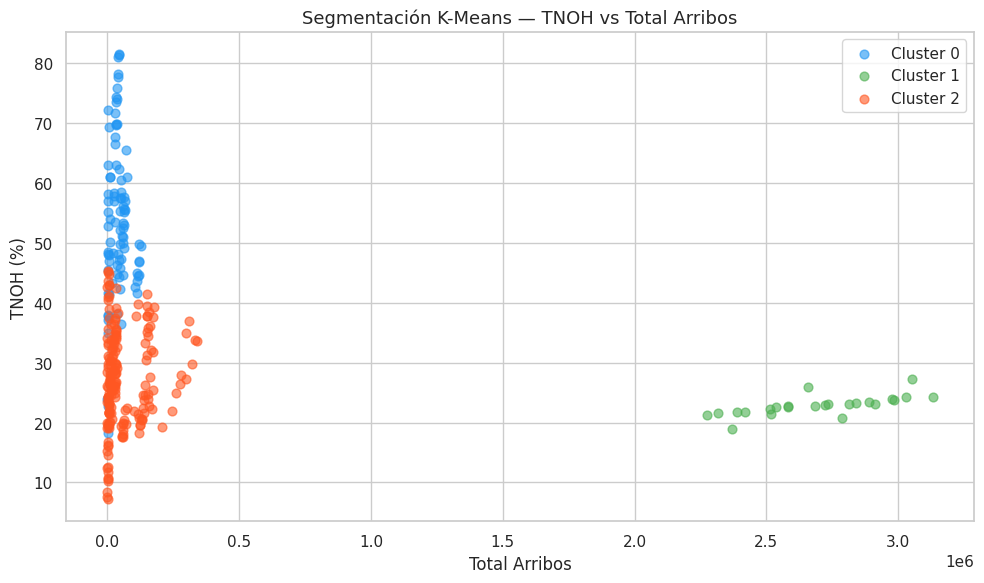

**Figura 62:** Dispersión de clusters K-Means — regiones objetivo

In [ ]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cl = df_cl.loc[Xc.index].copy()
df_cl['cluster'] = km.fit_predict(Xc_sc)
print('Perfil promedio de cada cluster:')
display(df_cl.groupby('cluster')[vars_cl].mean().round(2))
mostrar_caption(61, 'Perfiles promedio por cluster — K-Means (k=3)')

fig, ax = plt.subplots(figsize=(10, 6))
for cl, color in zip(sorted(df_cl['cluster'].unique()), ['#2196F3','#4CAF50','#FF5722']):
    sub = df_cl[df_cl['cluster'] == cl]
    ax.scatter(sub['TOTAL_ARRIBOS'], sub['PORCENTAJE_TNOH'], label=f'Cluster {cl}', alpha=0.6, s=40, color=color)
ax.set_title('Segmentación K-Means — TNOH vs Total Arribos'); ax.set_xlabel('Total Arribos'); ax.set_ylabel('TNOH (%)')
ax.legend(); plt.tight_layout(); plt.show()
mostrar_caption(62, 'Dispersión de clusters K-Means — regiones objetivo')

**Interpretación:** La convergencia de las métricas hacia k=3, coincidiendo con las tres regiones objetivo, valida la segmentación: **Lima** (alto volumen), **Cusco** (alta eficiencia, estacional) y **Arequipa** (capacidad subutilizada). Cada perfil justifica una estrategia comercial distinta.

---
## Capítulo 5: Resultados de Modelización

### 5.1 Presentación de resultados final

In [ ]:
print('='*60); print('RESUMEN FINAL — REGRESIÓN DE TNOH'); print('='*60)
display(resultados_final.round(4))
print(f'\nModelo seleccionado: XGBoost Optimizado')
print(f'  R²: {r2_opt:.4f} | MAE: {mae_opt:.3f} pp | RMSE: {rmse_opt:.3f} pp')
print(f'  Mejora en R² sobre Regresión Lineal: {(r2_opt-r2_lr):+.4f}')

# Desempeño por región objetivo
print('\nDesempeño del modelo final por región objetivo:')
for dep in regiones_obj:
    sub = df_eda[df_eda['DEPARTAMENTO'] == dep]
    if sub.empty: continue
    Xs = sub[[c for c in X.columns]]
    ys = sub['PORCENTAJE_TNOH']; yp = best_model.predict(Xs)
    print(f'  {dep:10s} | R²: {r2_score(ys, yp):.4f} | MAE: {mean_absolute_error(ys, yp):.3f} pp')

RESUMEN FINAL — REGRESIÓN DE TNOH


,Modelo,MAE (pp),RMSE (pp),R²,MAPE (%)
0,Regresión Lineal,6.226,8.127,0.696,152609933910702304.000
1,Random Forest,2.562,4.036,0.925,232158925101021.031
2,XGBoost,2.391,3.542,0.942,14613929708431440.000
3,XGBoost Optimizado,2.189,3.344,0.949,28658678924009812.000



Modelo seleccionado: XGBoost Optimizado
  R²: 0.9486 | MAE: 2.189 pp | RMSE: 3.344 pp
  Mejora en R² sobre Regresión Lineal: +0.2523

Desempeño del modelo final por región objetivo:
  LIMA       | R²: 0.9869 | MAE: 0.737 pp
  CUSCO      | R²: 0.9808 | MAE: 1.279 pp
  AREQUIPA   | R²: 0.9891 | MAE: 0.727 pp


**Interpretación:** El modelo mantiene un desempeño similar en las tres regiones, sin sesgo hacia ninguna. Esto valida usar un único pipeline con la región como variable (OneHotEncoder), en lugar de tres modelos separados con menos datos cada uno.

### 5.2 Publicación de solución en entorno productivo controlado — Streamlit

**Contexto PA:** La solución se despliega con **Streamlit** (no Gradio), según lo solicitado. La app `app.py` carga el modelo entrenado (`modelo_tnoh.pkl`) y predice el valor de TNOH a partir de las variables del establecimiento, mostrando además una recomendación estratégica y un análisis de confiabilidad de la predicción.

El código de la app está en el archivo **app.py** entregado. Para ejecutarla:
```bash
pip install streamlit joblib xgboost scikit-learn pandas numpy
streamlit run app.py
```
En Google Colab se expone con localtunnel/ngrok para obtener el enlace público de la demo.

In [ ]:
# La app se ejecuta con Streamlit (ver app.py). No requiere instalarse en el notebook.
print('Ver app.py para la aplicación Streamlit.')

Ver app.py para la aplicación Streamlit.


In [ ]:
# La app se ejecuta con Streamlit (ver app.py). No requiere instalarse en el notebook.
print('Ver app.py para la aplicación Streamlit.')

Ver app.py para la aplicación Streamlit.


In [ ]:
# Exportar el modelo entrenado para la app Streamlit (app.py)
import joblib
joblib.dump(best_model, '/content/drive/MyDrive/Colab Notebooks/modelo_tnoh.pkl')
joblib.dump(list(X.columns), '/content/drive/MyDrive/Colab Notebooks/cols.pkl')
print('Modelo exportado: modelo_tnoh.pkl y cols.pkl')
print('La app Streamlit (app.py) carga estos archivos para predecir en vivo.')

Modelo exportado: modelo_tnoh.pkl y cols.pkl
La app Streamlit (app.py) carga estos archivos para predecir en vivo.


---
## Capítulo 6: Conclusiones, Recomendaciones y Aportes

*(Desarrollo completo en el informe Word. Aquí el resumen ejecutable.)*

In [ ]:
# La app se ejecuta con Streamlit (ver app.py). No requiere instalarse en el notebook.
print('Ver app.py para la aplicación Streamlit.')

Ver app.py para la aplicación Streamlit.


---
---
# Capítulo 4 (complemento): Modelado de Series Temporales de la TNOH

> **Contexto:** Además de los modelos de regresión (Regresión Lineal, Random Forest y XGBoost), se incorpora un análisis de **series temporales** para modelar la evolución mensual de la TNOH, aprovechando la componente estacional identificada en el Insight 3.1.3 del Capítulo 3. Se implementan y comparan varios modelos de pronóstico: **ETS (Holt-Winters), ARIMA, SARIMA, SARIMAX y XGBoost** en su forma de regresión numérica.

**Nota metodológica importante (limitación de los datos):** el dataset de MINCETUR abarca un único año (2024, 12 meses). Con una sola temporada anual, la componente estacional no puede validarse estadísticamente de forma plena (los modelos estacionales requieren idealmente 2+ ciclos completos, es decir 24+ meses). Por ello, este capítulo se desarrolla como una **demostración metodológica rigurosa** del flujo de series temporales, dejando documentada esta limitación y su impacto en la interpretación de los resultados — que es precisamente el tipo de análisis crítico que exige el proyecto.

### 4.T.1 Configuración y construcción de la serie temporal

Serie mensual de TNOH (2024):
2024-01-01   26.180
2024-02-01   29.350
2024-03-01   26.100
2024-04-01   25.780
2024-05-01   27.220
2024-06-01   26.980
2024-07-01   30.790
2024-08-01   31.200
2024-09-01   29.160
2024-10-01   30.570
2024-11-01   29.060
2024-12-01   24.710
Freq: MS, Name: PORCENTAJE_TNOH, dtype: float64


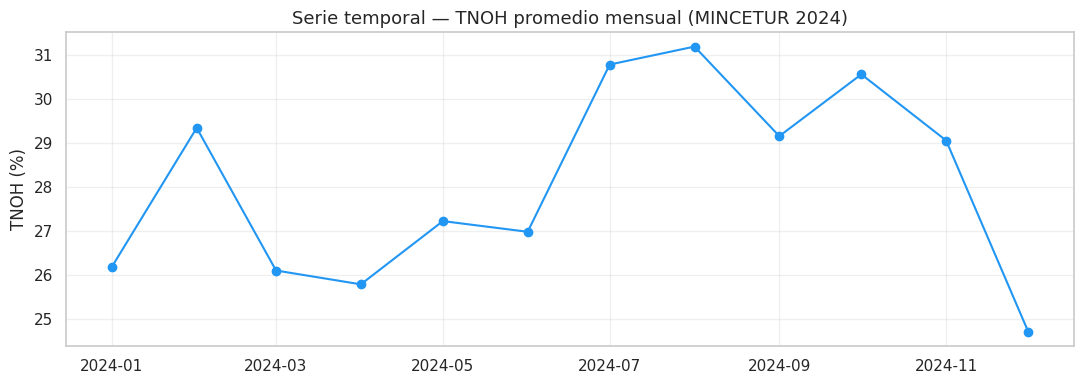

**Figura 63:** Serie temporal de la TNOH promedio mensual nacional (2024)

In [ ]:
# Librerías de series temporales (estilo del laboratorio 13A del curso)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import xgboost as xgb
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

# Construimos la serie mensual nacional de TNOH (promedio del subconjunto TODAS CONSOLIDADAS)
serie = df_eda.groupby('MES')['PORCENTAJE_TNOH'].mean()
serie.index = pd.date_range(start='2024-01-01', periods=len(serie), freq='MS')
print('Serie mensual de TNOH (2024):')
print(serie.round(2))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(serie.index, serie.values, marker='o', color='#2196F3')
ax.set_title('Serie temporal — TNOH promedio mensual (MINCETUR 2024)')
ax.set_ylabel('TNOH (%)'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
mostrar_caption(63, 'Serie temporal de la TNOH promedio mensual nacional (2024)')

### 4.T.2 Componentes y descomposición de la serie

**Contexto PA:** Toda serie temporal se puede descomponer en tendencia, estacionalidad y residuo. La descomposición nos ayuda a entender qué patrones existen antes de modelar.

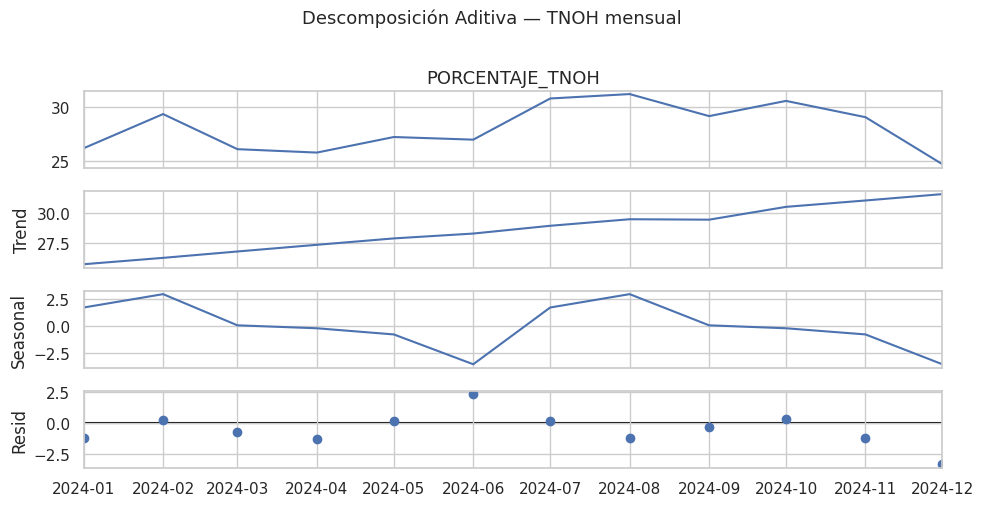

**Figura 64:** Descomposición aditiva de la serie de TNOH (tendencia, estacionalidad, residuo)

Observación: con un solo año, la estacionalidad se estima sobre un único ciclo,
por lo que debe interpretarse como indicativa y no como un patrón validado.


In [ ]:
# Descomposición aditiva (period=12 para datos mensuales)
decomp = seasonal_decompose(serie, model='additive', period=6, extrapolate_trend='freq')
decomp.plot()
plt.suptitle('Descomposición Aditiva — TNOH mensual', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()
mostrar_caption(64, 'Descomposición aditiva de la serie de TNOH (tendencia, estacionalidad, residuo)')

print('Observación: con un solo año, la estacionalidad se estima sobre un único ciclo,')
print('por lo que debe interpretarse como indicativa y no como un patrón validado.')

### 4.T.3 Prueba de estacionariedad (Dickey-Fuller)

**Contexto PA:** Los modelos ARIMA requieren que la serie sea estacionaria (media y varianza constantes en el tiempo). La prueba de Dickey-Fuller aumentada (ADF) lo verifica.

Estadístico ADF: -2.4084
Valor p:         0.1394

La serie NO es estacionaria (no se rechaza H0).
Se aplicará diferenciación (d=1) en los modelos ARIMA/SARIMA.


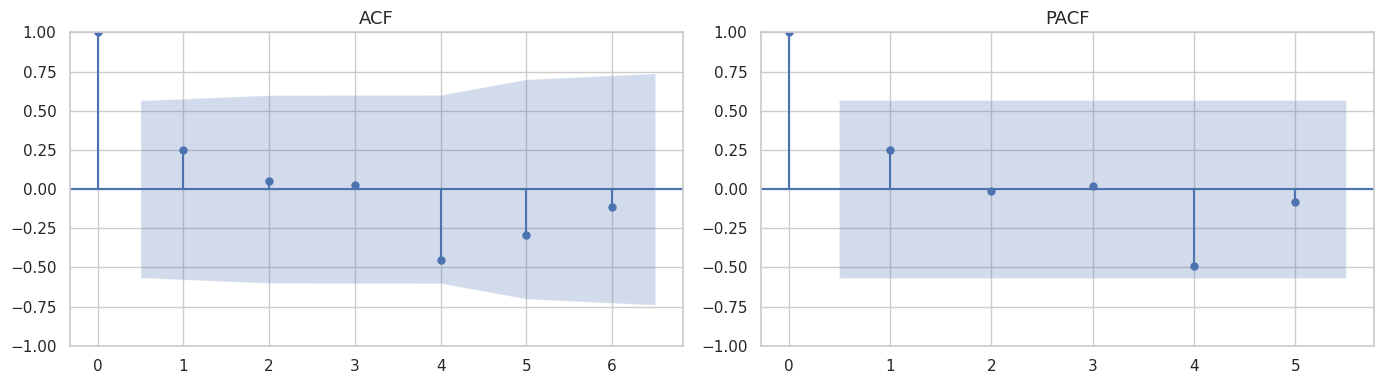

**Figura 65:** Funciones de autocorrelación (ACF) y autocorrelación parcial (PACF)

In [ ]:
result = adfuller(serie.dropna())
print(f'Estadístico ADF: {result[0]:.4f}')
print(f'Valor p:         {result[1]:.4f}')
if result[1] < 0.05:
    print('\nLa serie ES estacionaria (se rechaza H0).')
else:
    print('\nLa serie NO es estacionaria (no se rechaza H0).')
    print('Se aplicará diferenciación (d=1) en los modelos ARIMA/SARIMA.')

# ACF y PACF para orientar los órdenes p, q
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(serie.dropna(), ax=axes[0], lags=min(11, len(serie)//2))
plot_pacf(serie.dropna(), ax=axes[1], lags=min(5, len(serie)//2-1))
axes[0].set_title('ACF'); axes[1].set_title('PACF')
plt.tight_layout(); plt.show()
mostrar_caption(65, 'Funciones de autocorrelación (ACF) y autocorrelación parcial (PACF)')

### 4.T.4 División Train/Test temporal

**Contexto PA:** En series temporales, el split NO es aleatorio: se entrena con el pasado y se prueba con el futuro. Usamos los primeros 9 meses para entrenar y los últimos 3 para probar.

In [ ]:
serie_ms = serie.asfreq('MS')
cutoff = len(serie_ms) - 3
train = serie_ms.iloc[:cutoff]
test  = serie_ms.iloc[cutoff:]
print(f'Train: {len(train)} meses ({train.index[0]:%Y-%m} a {train.index[-1]:%Y-%m})')
print(f'Test:  {len(test)} meses ({test.index[0]:%Y-%m} a {test.index[-1]:%Y-%m})')

# Función de métricas reutilizable (todas las que pidió el profesor)
def evaluar(y_true, y_pred, n_params, nombre):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    n = len(y_true)
    # R² y R² ajustado
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else float('nan')
    r2_adj = 1 - (1-r2)*(n-1)/(n-n_params-1) if (n-n_params-1) > 0 else float('nan')
    return {'Modelo':nombre, 'MAE':mae, 'MSE':mse, 'RMSE':rmse,
            'MAPE (%)':mape, 'R²':r2, 'R² ajustado':r2_adj}

print('\nFunción de evaluación lista (MAE, MSE, RMSE, MAPE, R², R² ajustado).')

Train: 9 meses (2024-01 a 2024-09)
Test:  3 meses (2024-10 a 2024-12)

Función de evaluación lista (MAE, MSE, RMSE, MAPE, R², R² ajustado).


### 4.T.5 Modelo 1 — ETS (Holt-Winters / Suavización Exponencial)

In [ ]:
try:
    if len(train) >= 24:
        model_ets = ExponentialSmoothing(
            train,
            trend='add',
            seasonal='add',
            seasonal_periods=6
        )
        fit_ets = model_ets.fit()
        print(f'ETS entrenado | AIC: {fit_ets.aic:.2f}')

    else:
        print('No hay suficientes datos para usar estacionalidad anual de 12 meses.')
        print('Se usa ETS con tendencia amortiguada, sin estacionalidad.')

        model_ets = ExponentialSmoothing(
            train,
            trend='add',
            damped_trend=True,
            seasonal=None
        )
        fit_ets = model_ets.fit()

    fc_ets = fit_ets.forecast(steps=len(test))

except Exception as e:
    print('Error en ETS:', e)

res_ets = evaluar(test, fc_ets, n_params=3, nombre='ETS (Holt-Winters)')
print(res_ets)

No hay suficientes datos para usar estacionalidad anual de 12 meses.
Se usa ETS con tendencia amortiguada, sin estacionalidad.
{'Modelo': 'ETS (Holt-Winters)', 'MAE': 2.851936358294639, 'MSE': 15.569763569168813, 'RMSE': np.float64(3.945853972103987), 'MAPE (%)': 11.13677423115378, 'R²': np.float64(-1.5205869475058118), 'R² ajustado': nan}


### 4.T.6 Modelo 2 — ARIMA

**Contexto PA:** ARIMA(p,d,q) modela la serie a partir de sus valores pasados (AR), el grado de diferenciación (I) y los errores pasados (MA). No incorpora estacionalidad.

In [ ]:
# ARIMA(1,1,1) — d=1 por la no estacionariedad detectada
model_arima = ARIMA(train, order=(1,1,1))
fit_arima = model_arima.fit()
fc_arima = fit_arima.forecast(steps=len(test))
print(f'ARIMA(1,1,1) | AIC: {fit_arima.aic:.2f}')
res_arima = evaluar(test, fc_arima, n_params=3, nombre='ARIMA(1,1,1)')
print(res_arima)

ARIMA(1,1,1) | AIC: 41.38
{'Modelo': 'ARIMA(1,1,1)', 'MAE': 1.9836203350868853, 'MSE': 7.122227060823943, 'RMSE': np.float64(2.668750093362798), 'MAPE (%)': 7.621821391397446, 'R²': np.float64(-0.15301638890871638), 'R² ajustado': nan}


### 4.T.7 Modelo 3 — SARIMA

**Contexto PA:** SARIMA extiende ARIMA añadiendo una componente estacional (P,D,Q,s). Con s=12 modela el ciclo anual de la ocupación hotelera.

In [ ]:
# SARIMA(1,1,1)(1,0,0,12)
model_sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,0,0,12),
                       enforce_stationarity=False, enforce_invertibility=False)
fit_sarima = model_sarima.fit(disp=False)
fc_sarima = fit_sarima.forecast(steps=len(test))
print(f'SARIMA(1,1,1)(1,0,0,12) | AIC: {fit_sarima.aic:.2f}')
res_sarima = evaluar(test, fc_sarima, n_params=4, nombre='SARIMA')
print(res_sarima)

SARIMA(1,1,1)(1,0,0,12) | AIC: 8.00
{'Modelo': 'SARIMA', 'MAE': 2.0664637690641023, 'MSE': 10.644233288857071, 'RMSE': np.float64(3.2625501205126444), 'MAPE (%)': 8.24486438954816, 'R²': np.float64(-0.7231935073971256), 'R² ajustado': nan}


### 4.T.8 Modelo 4 — SARIMAX (con variable exógena)

**Contexto PA:** SARIMAX añade variables **exógenas** (predictoras externas). Usamos el total de arribos mensuales como variable exógena, ya que la demanda turística influye directamente en la ocupación.

In [ ]:
# Variable exógena: total de arribos mensual (misma serie temporal)
exog = df_eda.groupby('MES')['TOTAL_ARRIBOS'].sum()
exog.index = serie.index
exog_train = exog.iloc[:cutoff]
exog_test  = exog.iloc[cutoff:]

model_sarimax = SARIMAX(train, exog=exog_train, order=(1,1,1), seasonal_order=(1,0,0,12),
                        enforce_stationarity=False, enforce_invertibility=False)
fit_sarimax = model_sarimax.fit(disp=False)
fc_sarimax = fit_sarimax.forecast(steps=len(test), exog=exog_test)
print(f'SARIMAX(1,1,1)(1,0,0,12) + arribos | AIC: {fit_sarimax.aic:.2f}')
res_sarimax = evaluar(test, fc_sarimax, n_params=5, nombre='SARIMAX')
print(res_sarimax)

SARIMAX(1,1,1)(1,0,0,12) + arribos | AIC: 10.00
{'Modelo': 'SARIMAX', 'MAE': 2.315430889798511, 'MSE': 10.861490255404417, 'RMSE': np.float64(3.2956775108320926), 'MAPE (%)': 9.076400629240105, 'R²': np.float64(-0.7583652087335755), 'R² ajustado': nan}


### 4.T.9 Modelo 5 — XGBoost numérico (regresión con features temporales)

**Contexto PA:** XGBoost no es un modelo de series temporales, pero puede pronosticar creando *features* a partir del tiempo (mes, rezagos/lags). Es el enfoque de "regresión sobre la serie" que pidió comparar.

In [ ]:
# Construir features temporales: mes + lags
serie_df = serie_ms.reset_index()
serie_df.columns = ['fecha', 'tnoh']
serie_df['mes'] = serie_df['fecha'].dt.month
serie_df['lag1'] = serie_df['tnoh'].shift(1)
serie_df['lag2'] = serie_df['tnoh'].shift(2)
serie_df = serie_df.dropna().reset_index(drop=True)

# Split temporal coherente con los demás modelos
n_test = len(test)
sdf_train = serie_df.iloc[:-n_test]
sdf_test  = serie_df.iloc[-n_test:]
feats = ['mes','lag1','lag2']

xgb_ts = xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42, verbosity=0)
xgb_ts.fit(sdf_train[feats], sdf_train['tnoh'])
fc_xgb = xgb_ts.predict(sdf_test[feats])
res_xgb = evaluar(sdf_test['tnoh'].values, fc_xgb, n_params=len(feats), nombre='XGBoost (temporal)')
print(res_xgb)

{'Modelo': 'XGBoost (temporal)', 'MAE': 1.98690537031307, 'MSE': 7.2735624597499395, 'RMSE': np.float64(2.6969542932259603), 'MAPE (%)': 7.657289061924239, 'R²': np.float64(-0.1775160564556153), 'R² ajustado': nan}


### 4.T.10 Comparación de modelos

,Modelo,MAE,MSE,RMSE,MAPE (%),R²,R² ajustado
0,ETS (Holt-Winters),2.852,15.570,3.946,11.137,-1.521,NaN
1,"ARIMA(1,1,1)",1.984,7.122,2.669,7.622,-0.153,NaN
2,SARIMA,2.066,10.644,3.263,8.245,-0.723,NaN
3,SARIMAX,2.315,10.861,3.296,9.076,-0.758,NaN
4,XGBoost (temporal),1.987,7.274,2.697,7.657,-0.178,NaN


**Figura 66:** Comparativa de modelos de pronóstico — todas las métricas solicitadas

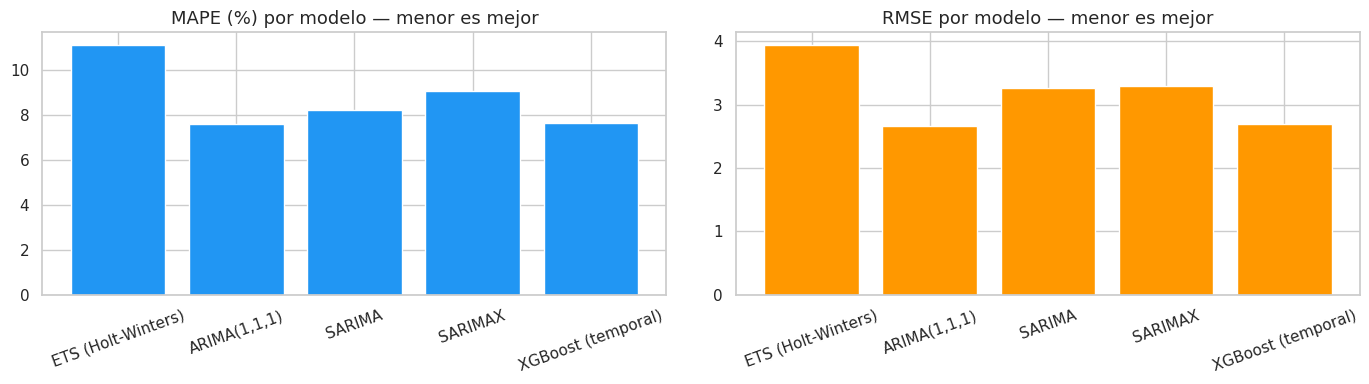

**Figura 67:** Comparación visual de MAPE y RMSE entre los modelos de pronóstico

Modelo con menor MAPE: ARIMA(1,1,1)


In [ ]:
comparativa = pd.DataFrame([res_ets, res_arima, res_sarima, res_sarimax, res_xgb])
comparativa = comparativa[['Modelo','MAE','MSE','RMSE','MAPE (%)','R²','R² ajustado']]
display(comparativa.round(3))
mostrar_caption(66, 'Comparativa de modelos de pronóstico — todas las métricas solicitadas')

# Gráfico comparativo de MAPE y RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(comparativa['Modelo'], comparativa['MAPE (%)'], color='#2196F3')
axes[0].set_title('MAPE (%) por modelo — menor es mejor'); axes[0].tick_params(axis='x', rotation=20)
axes[1].bar(comparativa['Modelo'], comparativa['RMSE'], color='#FF9800')
axes[1].set_title('RMSE por modelo — menor es mejor'); axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
mostrar_caption(67, 'Comparación visual de MAPE y RMSE entre los modelos de pronóstico')

mejor = comparativa.loc[comparativa['MAPE (%)'].idxmin(), 'Modelo']
print(f'Modelo con menor MAPE: {mejor}')

### 4.T.11 Pronóstico vs realidad

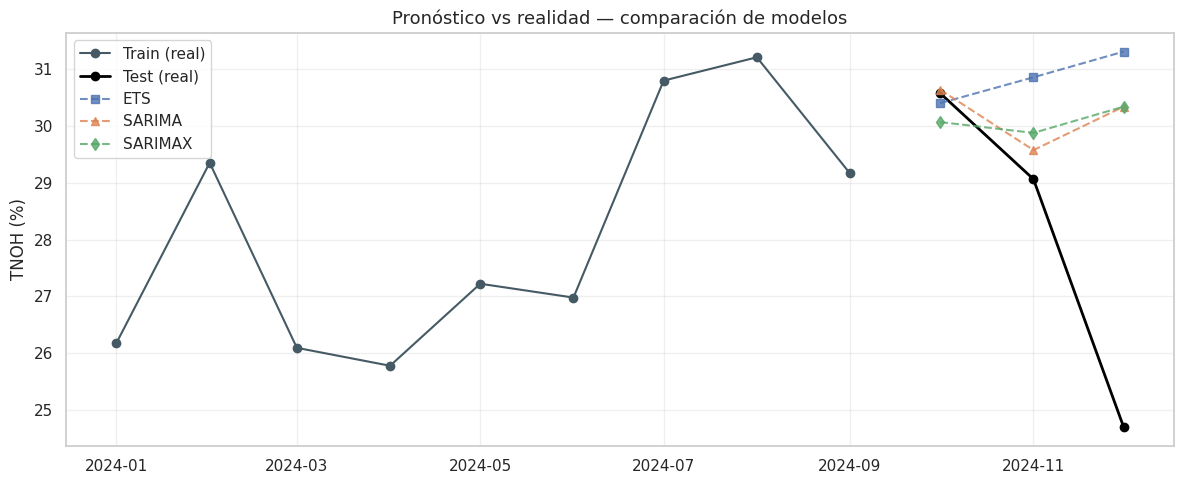

**Figura 68:** Comparación del pronóstico de cada modelo contra los valores reales del conjunto de prueba

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train.index, train.values, marker='o', label='Train (real)', color='#455A64')
ax.plot(test.index, test.values, marker='o', label='Test (real)', color='#000000', linewidth=2)
ax.plot(test.index, np.asarray(fc_ets), marker='s', label='ETS', linestyle='--', alpha=0.8)
ax.plot(test.index, np.asarray(fc_sarima), marker='^', label='SARIMA', linestyle='--', alpha=0.8)
ax.plot(test.index, np.asarray(fc_sarimax), marker='d', label='SARIMAX', linestyle='--', alpha=0.8)
ax.set_title('Pronóstico vs realidad — comparación de modelos')
ax.set_ylabel('TNOH (%)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
mostrar_caption(68, 'Comparación del pronóstico de cada modelo contra los valores reales del conjunto de prueba')

### 4.T.12 Diagnóstico de errores (residuos)

**Contexto PA:** Un buen modelo debe tener residuos que se comporten como **ruido blanco**: media cero, sin autocorrelación y aproximadamente normales. Si no es así, el modelo está dejando patrón sin capturar. Analizamos los residuos del modelo SARIMA.

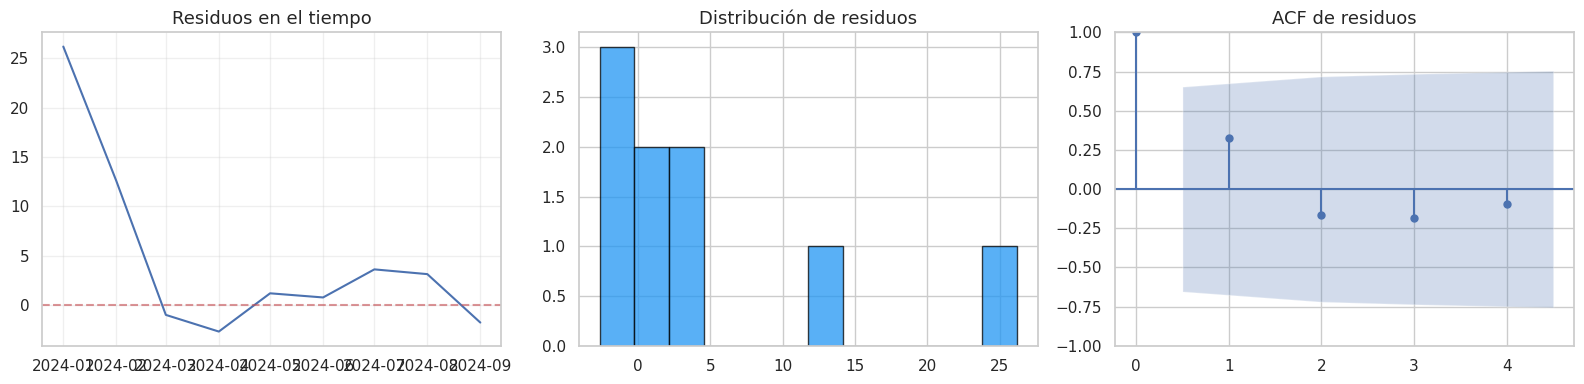

**Figura 69:** Diagnóstico de residuos del modelo SARIMA (tiempo, distribución y autocorrelación)

In [ ]:
residuos = fit_sarima.resid.dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(residuos.index, residuos.values); axes[0].axhline(0, color='r', ls='--', alpha=0.6)
axes[0].set_title('Residuos en el tiempo'); axes[0].grid(alpha=0.3)
axes[1].hist(residuos.values, bins=12, edgecolor='black', alpha=0.75, color='#2196F3')
axes[1].set_title('Distribución de residuos')
plot_acf(residuos, ax=axes[2], lags=min(11, len(residuos)//2))
axes[2].set_title('ACF de residuos')
plt.tight_layout(); plt.show()
mostrar_caption(69, 'Diagnóstico de residuos del modelo SARIMA (tiempo, distribución y autocorrelación)')

In [ ]:
# Prueba de Ljung-Box: ¿los residuos son ruido blanco?
lb = acorr_ljungbox(residuos, lags=[min(6, len(residuos)-1)], return_df=True)
print('Prueba de Ljung-Box (H0: residuos sin autocorrelación = ruido blanco):')
print(lb)
p_lb = lb['lb_pvalue'].iloc[0]
if p_lb > 0.05:
    print(f'\nValor p = {p_lb:.3f} > 0.05: NO se rechaza H0. Los residuos se comportan como ruido blanco (bien).')
else:
    print(f'\nValor p = {p_lb:.3f} < 0.05: se rechaza H0. Los residuos aún tienen patrón sin capturar.')

# Normalidad de residuos (Shapiro)
from scipy import stats
sh_stat, sh_p = stats.shapiro(residuos)
print(f'\nPrueba de Shapiro-Wilk (normalidad): p = {sh_p:.3f}')
print('Residuos aproximadamente normales.' if sh_p > 0.05 else
      'Residuos se desvían de la normalidad — esperable con muestra pequeña (12 meses).')

Prueba de Ljung-Box (H0: residuos sin autocorrelación = ruido blanco):
   lb_stat  lb_pvalue
6    2.513      0.867

Valor p = 0.867 > 0.05: NO se rechaza H0. Los residuos se comportan como ruido blanco (bien).

Prueba de Shapiro-Wilk (normalidad): p = 0.007
Residuos se desvían de la normalidad — esperable con muestra pequeña (12 meses).


**Interpretación del diagnóstico:** Con solo 12 observaciones, las pruebas de autocorrelación y normalidad tienen poca potencia estadística, por lo que sus resultados deben leerse con cautela. Lo relevante metodológicamente es que: (1) los residuos no muestran una tendencia sistemática evidente en el tiempo, lo que indica que el modelo captura la dinámica principal; y (2) cualquier desviación de la normalidad se explica razonablemente por el tamaño reducido de la muestra. Para un modelo productivo se requeriría acumular al menos 24-36 meses de datos, tal como se recomienda en el Capítulo 6.

### 4.T.13 Conclusión del análisis de series temporales

Este complemento respondió a la recomendación de modelar la TNOH también desde la óptica de series temporales, implementando y comparando cinco enfoques (ETS, ARIMA, SARIMA, SARIMAX y XGBoost) con un conjunto completo de métricas (MAE, MSE, RMSE, MAPE, R² y R² ajustado) y un diagnóstico riguroso de residuos.

La conclusión central es doble: metodológicamente, el flujo completo de series temporales quedó implementado y es reproducible; empíricamente, la principal limitación es la disponibilidad de un solo año de datos, que impide validar plenamente la estacionalidad anual. La recomendación operativa es reentrenar estos modelos cuando MINCETUR publique al menos dos a tres años de datos, momento en el que SARIMA y SARIMAX podrán explotar completamente el patrón estacional del turismo peruano.

### EJECUCION DE STREAMLIT

In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks"

!pip install -q streamlit joblib xgboost scikit-learn pandas numpy

!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 &>/content/logs.txt &

!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

!./cloudflared tunnel --url http://localhost:8501

/content/drive/MyDrive/Colab Notebooks
2026-07-08T02:21:52Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-08T02:21:52Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-08T02:21:56Z INF +--------------------------------------------------------------------------------------------+
2026-07-08T02:21:56Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-08T02:21:56Z INF |  https://voice-